#  **순수 물리적 지표만으로 베터리 RUL 예측 머신러닝 모델링**

##  **완전히 제외되는 변수들**

### 1. dis_Capacity 관련 (8개 제외)

```python
 dis_Capacity                 # 원본 방전 용량
 dis_Capacity_norm            # 정규화
 capacity_retention           # 용량 유지율
 dis_Capacity_roll_mean5      # 이동평균
 dis_Capacity_roll_std5       # 이동 표준편차
 dis_Capacity_diff1           # 변화량
 dis_Capacity_pct_change      # 변화율
 capacity_per_cycle           # 사이클당 용량
```

### 2. SOH 관련 (10개 제외)

```python
 SOH_target                   # SOH = f(dis_Capacity)
 SOH_target_ma5               # SOH 이동평균 5
 SOH_target_ma10              # SOH 이동평균 10
 SOH_target_diff1             # SOH 변화량
 SOH_target_roll_mean5        # SOH rolling mean
 SOH_target_roll_std5         # SOH rolling std
 soh_degradation_rate         # SOH 감소율
 기타 모든 SOH 파생 변수
```

**왜 SOH도 제외하는지**

```python
SOH (State of Health) 정의:

SOH = (현재 용량 / 초기 용량) × 100
    = (dis_Capacity / dis_Capacity_초기) × 100

즉:
dis_Capacity ─────→ SOH ─────→ RUL
  (정답지)        (정답지)    (타겟)

→ SOH는 dis_Capacity에서 직접 계산됨!
→ SOH로 RUL 예측 = 정답지로 정답 맞추기
→ 데이터 유수 발생
```

### 3. global_cycle 관련 (1개 제외)

```python
 global_cycle                 # 총 사용 횟수
```

**왜 global_cycle도 제외하는지**

```python
global_cycle과 RUL의 관계:

RUL = Total_cycles - global_cycle

예시:
- 전체 수명: 168 cycles
- global_cycle = 70  → RUL ≈ 98
- global_cycle = 100 → RUL ≈ 68
- global_cycle = 150 → RUL ≈ 18

즉:
RUL ≈ f(global_cycle)  ← 거의 직접적 관계임

→ global_cycle로 RUL 예측 = 정답지 사용
→ 모델이 "cycle 많음 = 수명 짧음"만 학습
→ 물리적 메커니즘 학습 안 함
```

---

##  **사용하는 변수들 (순수 물리적 지표)**

### 1. 임피던스 (배터리 내부 저항)

```python
 imp_Re                       # 전해액 저항
 imp_Rct                      # 전하 전달 저항
 imp2_Battery_impedance_mag   # 배터리 임피던스 크기
 imp2_Rectified_Impedance_mag # 정류 임피던스
```

**물리적 의미**: SEI 층 성장, 전해질 분해 → 임피던스 증가

### 2. 열화 지표

```python
 dis_IR_drop                  # IR 강하 (내부 저항 × 전류)
 dis_dV_dQ_early              # 전압-용량 곡선 변화
```

**물리적 의미**: 내부 저항 증가, 전극 재료 열화

### 3. 충방전 시간 패턴

```python
 dis_time                     # 방전 시간
 cha_time                     # 충전 시간
 dis_time_roll_mean5          # 방전 시간 추세
 cha_time_roll_mean5          # 충전 시간 추세
```

**물리적 의미**: 용량 감소를 간접 반영 (시간 ∝ 용량)

### 4. 전압/전류 패턴

```python
 dis_V_diff, cha_V_diff       # 전압 변화
 dis_I_diff, cha_I_diff       # 전류 변화
 dis_V_mean, cha_V_mean       # 평균 전압
```

### 5. 온도

```python
 dis_T_max, cha_T_max         # 최대 온도
 dis_T_mean, cha_T_mean       # 평균 온도
```

## 1. 환경 설정 및 라이브러리

In [1]:
# 기본 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# 머신러닝
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb

# 시각화 설정

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 폰트
plt.rcParams['axes.unicode_minus'] = False

print(" 환경 설정 완료")

 환경 설정 완료


## 2. 데이터 로드 및 기본 탐색

In [2]:
# 데이터 로드

df = pd.read_csv('df_cycle_B5671836_NN.csv')
print("="*80)
print("데이터셋 기본 정보")
print("="*80)
print(f"전체 행 수: {len(df):,}")
print(f"전체 열 수: {len(df.columns)}")
print(f"\n배터리 분포:")
print(df['battery_id'].value_counts())
print("\n" + "="*80)
print("타겟 변수 통계")
print("="*80)
print(df[['SOH_target', 'RUL', 'is_EOL']].describe())
print("\n" + "="*80)
print("배터리별 SOH 감소")
print("="*80)

for battery_id in sorted(df['battery_id'].unique()):
    battery_data = df[df['battery_id'] == battery_id].sort_values('global_cycle')
    soh_start = battery_data['SOH_target'].iloc[0]
    soh_end = battery_data['SOH_target'].iloc[-1]
    cycles = len(battery_data)
    print(f"{battery_id}: {soh_start:.2f}% → {soh_end:.2f}% ({cycles} cycles)")

# 데이터 미리보기
df.head()

데이터셋 기본 정보
전체 행 수: 829
전체 열 수: 138

배터리 분포:
battery_id
B0036    196
B0005    167
B0006    167
B0007    167
B0018    132
Name: count, dtype: int64

타겟 변수 통계
       SOH_target         RUL
count  829.000000  829.000000
mean    85.609180   72.098914
std     11.018519   52.105267
min     56.689285    0.000000
25%     76.508521   27.000000
50%     87.998869   68.000000
75%     95.057965  112.000000
max    135.698262  195.000000

배터리별 SOH 감소
B0005: 100.00% → 71.38% (167 cycles)
B0006: 100.00% → 58.25% (167 cycles)
B0007: 100.00% → 75.75% (167 cycles)
B0018: 100.00% → 72.29% (132 cycles)
B0036: 100.00% → 86.56% (196 cycles)


,global_cycle,cha_t_cycle,cha_start,cha_time,cha_V_first,cha_V_last,cha_V_diff,cha_V_mean,cha_V_max,cha_V_min,...,imp2_Current_ratio_real_status,imp2_Current_ratio_imag_status,imp2_Current_ratio_mag_status,imp2_Battery_impedance_real_status,imp2_Battery_impedance_imag_status,imp2_Battery_impedance_mag_status,imp2_Rectified_Impedance_real_status,imp2_Rectified_Impedance_imag_status,imp2_Rectified_Impedance_mag_status,battery_id
0,1,0,2008-04-02 13:08:17,7597.875,3.873017,4.191078,0.318060,4.187420,4.209949,3.479394,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B0005
1,2,2,2008-04-02 16:37:51,10516.000,3.325055,4.189062,0.864007,4.058826,4.213016,3.001951,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B0005
2,3,4,2008-04-02 20:55:40,10484.547,3.352604,4.187398,0.834795,4.058139,4.212788,3.035879,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B0005
3,4,6,2008-04-03 01:12:38,10397.890,3.378799,4.188055,0.809256,4.058905,4.212924,3.066145,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B0005
4,5,8,2008-04-03 05:27:49,10495.203,3.372871,4.188438,0.815568,4.058330,4.212874,3.063766,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B0005


## 2.5 데이터 품질 검증 및 이상치 처리

배터리 데이터에서 물리적으로 불가능한 값들을 사전에 제거.

### 이상치 처리 대상
1. **SOH_target > 110%**: 물리적으로 불가능 (배터리는 100% 초과 불가)

### 처리 방법
- **앞뒤 평균으로 대체**: 시계열 연속성 유지

In [3]:
print("="*80)
print("SOH 및 Capacity 이상치 탐지 및 처리")
print("="*80)

# 배터리별로 이상치 처리를 수행하는 함수
def detect_and_correct_outliers(df, battery_col='battery_id', 
                                 soh_col='SOH_target', 
                                 capacity_col='dis_Capacity',
                                 cycle_col='dis_t_cycle',
                                 threshold=110.0, 
                                 method='front_back_avg'):
    """
    배터리별로 SOH 및 Capacity 이상치를 탐지하고 처리
    Parameters:
    -----------
    threshold : float
        이상치 판단 임계값 (기본: 110%)
    Returns:
    --------
    df_corrected : pd.DataFrame
        이상치가 처리된 데이터프레임
    """
    df_corrected = df.copy()
    report = {}
    total_outliers = 0
    
    # 배터리별로 처리
    for battery_id in df[battery_col].unique():
        battery_mask = df_corrected[battery_col] == battery_id
        df_battery = df_corrected[battery_mask].copy()
        
        # 사이클 순서로 정렬
        df_battery = df_battery.sort_values(cycle_col).reset_index(drop=True)
        
        # 이상치 탐지 (SOH 기준)
        outlier_mask = df_battery[soh_col] > threshold
        outlier_indices = df_battery[outlier_mask].index.tolist()
        
        if len(outlier_indices) > 0:
            corrections = []
            
            # 앞뒤 평균으로 대체 (SOH와 dis_Capacity 모두)
            for idx in outlier_indices:
                orig_soh = df_battery.loc[idx, soh_col]
                orig_cap = df_battery.loc[idx, capacity_col]
                cycle = df_battery.loc[idx, cycle_col]
                
                if idx > 0 and idx < len(df_battery) - 1:
                    # SOH 처리
                    prev_soh = df_battery.loc[idx-1, soh_col]
                    next_soh = df_battery.loc[idx+1, soh_col]
                    new_soh = (prev_soh + next_soh) / 2
                    
                    # dis_Capacity 처리
                    prev_cap = df_battery.loc[idx-1, capacity_col]
                    next_cap = df_battery.loc[idx+1, capacity_col]
                    new_cap = (prev_cap + next_cap) / 2
                elif idx == 0:
                    new_soh = df_battery.loc[idx+1, soh_col]
                    new_cap = df_battery.loc[idx+1, capacity_col]
                else:
                    new_soh = df_battery.loc[idx-1, soh_col]
                    new_cap = df_battery.loc[idx-1, capacity_col]
                
                df_battery.loc[idx, soh_col] = new_soh
                df_battery.loc[idx, capacity_col] = new_cap
                
                corrections.append({
                    'cycle': int(cycle),
                    'original_soh': orig_soh,
                    'corrected_soh': new_soh,
                    'original_capacity': orig_cap,
                    'corrected_capacity': new_cap
                })
            
            # 원본 데이터프레임에 반영
            original_indices = df_corrected[battery_mask].index
            df_corrected.loc[original_indices, soh_col] = df_battery[soh_col].values
            df_corrected.loc[original_indices, capacity_col] = df_battery[capacity_col].values
            
            report[battery_id] = {
                'outlier_count': len(outlier_indices),
                'corrections': corrections
            }
            total_outliers += len(outlier_indices)
    
    print(f"\n 전체 이상치 처리 완료: {total_outliers}개")
    print(f"   영향받은 배터리: {len(report)}개\n")
    
    # 배터리별 상세 리포트
    if len(report) > 0:
        print("-"*80)
        print(f"{'배터리 ID':<12} {'이상치':>8} {'처리 내역':>55}")
        print("-"*80)
        
        for battery_id, info in report.items():
            count = info['outlier_count']
            corrections = info['corrections']
            
            for i, corr in enumerate(corrections):
                if i == 0:
                    print(f"{battery_id:<12} {count:>8}개   ", end="")
                else:
                    print(f"{'':<12} {'':<8}   ", end="")
                
                print(f"Cycle {corr['cycle']:3d}: SOH {corr['original_soh']:6.2f}→{corr['corrected_soh']:6.2f}%, "
                      f"Cap {corr['original_capacity']:.3f}→{corr['corrected_capacity']:.3f} Ah")
        
        print("-"*80)
    else:
        print("이상치가 발견되지 않았습니다. 데이터 품질이 양호합니다.")
    
    return df_corrected, report

# 이상치 처리 실행
df_cleaned, outlier_report = detect_and_correct_outliers(
    df,
    battery_col='battery_id',
    soh_col='SOH_target',
    capacity_col='dis_Capacity',
    cycle_col='dis_t_cycle',
    threshold=110.0,  # SOH > 110%를 이상치로 판단
    method='front_back_avg'
)

# 통계 비교
print("\n" + "="*80)
print("데이터 품질 검증 결과")
print("="*80)
print(f"{'항목':<30} {'처리 전':>15} {'처리 후':>15} {'변화':>15}")
print("-"*80)

# SOH 통계
orig_mean = df['SOH_target'].mean()
clean_mean = df_cleaned['SOH_target'].mean()
print(f"{'SOH 평균 (%)':<30} {orig_mean:>14.2f}% {clean_mean:>14.2f}% {clean_mean-orig_mean:>14.2f}%")

orig_max = df['SOH_target'].max()
clean_max = df_cleaned['SOH_target'].max()
print(f"{'SOH 최대값 (%)':<30} {orig_max:>14.2f}% {clean_max:>14.2f}% {clean_max-orig_max:>14.2f}%")

# Capacity 통계
orig_cap_mean = df['dis_Capacity'].mean()
clean_cap_mean = df_cleaned['dis_Capacity'].mean()
print(f"{'Capacity 평균 (Ah)':<30} {orig_cap_mean:>14.4f} {clean_cap_mean:>14.4f} {clean_cap_mean-orig_cap_mean:>14.4f}")

orig_cap_max = df['dis_Capacity'].max()
clean_cap_max = df_cleaned['dis_Capacity'].max()
print(f"{'Capacity 최대값 (Ah)':<30} {orig_cap_max:>14.4f} {clean_cap_max:>14.4f} {clean_cap_max-orig_cap_max:>14.4f}")

print("-"*80)
print(f"{'데이터 포인트 수':<30} {len(df):>15} {len(df_cleaned):>15} {len(df_cleaned)-len(df):>15}")
print("="*80)

# 처리된 데이터로 교체
df = df_cleaned.copy()
print("\n SOH 및 Capacity 이상치 처리 완료")
print("   이후 모든 분석은 정제된 데이터로 진행.")
print("="*80)


SOH 및 Capacity 이상치 탐지 및 처리

 전체 이상치 처리 완료: 2개
   영향받은 배터리: 1개

--------------------------------------------------------------------------------
배터리 ID            이상치                                                   처리 내역
--------------------------------------------------------------------------------
B0036               2개   Cycle 112: SOH 110.24→ 97.96%, Cap 1.985→1.764 Ah
                        Cycle 278: SOH 135.70→ 93.54%, Cap 2.444→1.685 Ah
--------------------------------------------------------------------------------

데이터 품질 검증 결과
항목                                        처리 전            처리 후              변화
--------------------------------------------------------------------------------
SOH 평균 (%)                              85.61%          85.54%          -0.07%
SOH 최대값 (%)                            135.70%         100.18%         -35.51%
Capacity 평균 (Ah)                       1.6102         1.6090        -0.0012
Capacity 최대값 (Ah)                      2.4441         2.035

## 3. Feature 그룹 분석 및 선택

In [4]:
print("="*80)
print("Feature 그룹 분류")
print("="*80)

# Feature 그룹별 분류
cha_features = [col for col in df.columns if col.startswith('cha_')]
dis_features = [col for col in df.columns if col.startswith('dis_')]
imp_features = [col for col in df.columns if col.startswith('imp_') and not col.startswith('imp1_') and not col.startswith('imp2_')]
imp1_features = [col for col in df.columns if col.startswith('imp1_')]
imp2_features = [col for col in df.columns if col.startswith('imp2_')]
status_features = [col for col in df.columns if '_status' in col]

print(f"충전(cha_): {len(cha_features)}개")
print(f"방전(dis_): {len(dis_features)}개")
print(f"임피던스(imp_): {len(imp_features)}개")
print(f"임피던스1(imp1_): {len(imp1_features)}개")
print(f"임피던스2(imp2_): {len(imp2_features)}개")
print(f"상태(status): {len(status_features)}개")

# 결측치 분석

print("\n" + "="*80)
print("결측치 분석")
print("="*80)

missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    '결측치 수': missing_counts,
    '결측치 비율(%)': missing_pct
})

missing_df = missing_df[missing_df['결측치 수'] > 0].sort_values('결측치 수', ascending=False)

print(f"결측치가 있는 칼럼: {len(missing_df)}개")
print("\n결측치 비율이 높은 상위 10개 칼럼:")
print(missing_df.head(10))

Feature 그룹 분류
충전(cha_): 31개
방전(dis_): 28개
임피던스(imp_): 7개
임피던스1(imp1_): 30개
임피던스2(imp2_): 37개
상태(status): 34개

결측치 분석
결측치가 있는 칼럼: 77개

결측치 비율이 높은 상위 10개 칼럼:
                               결측치 수  결측치 비율(%)
cha_imp                          353      42.58
imp_t_cycle                      353      42.58
imp_start                        353      42.58
imp_dis                          353      42.58
imp2_start                       335      40.41
imp2_t_cycle                     335      40.41
dis_imp2                         335      40.41
imp2_cha                         335      40.41
imp2_Re                           61       7.36
imp2_Rectified_Impedance_imag     61       7.36


In [5]:

# ============================================================
# Feature 선택 - 중요 변수 강화
# ============================================================
print("="*80)
print(" Feature 선택 - 중요 변수 명시적 추가")
print("="*80)

# ============================================================
# 1. 정답지 (Target)
capacity_features = [
    'dis_Capacity',  # 원본 - 가장 중요
]

# 2. 저항 및 열화 지표 
resistance_degradation_features = [
    'imp_Re',          # 전해액 저항
    'imp_Rct',         # 충전 반응 저항
    'imp2_Re',         # 전해액 저항 (측정2)
    'imp2_Rct',        # 충전 반응 저항 (측정2)
    'imp1_Battery_impedance_mag',      # 배터리 임피던스 (측정1)
    'imp2_Battery_impedance_mag',      # 배터리 임피던스 (측정2)
    'imp1_Rectified_Impedance_mag',    # 정류 임피던스 (측정1)
    'imp2_Rectified_Impedance_mag',    # 정류 임피던스 (측정2)
    'dis_IR_drop',     # IR 강하
    'dis_dV_dQ_early', # dV/dQ (조기 열화 감지)
]

# 3. 충전 및 방전 동작 지표
charge_discharge_features = [
    'dis_time',        # 방전 시간
    'cha_time',        # 충전 시간
    'cha_ratio_cc',    # CC 비율
    # cha_t_cv_start는 데이터에 없으면 제외
]

# 4. 환경 및 통계 지표
env_features = [
    'global_cycle',    # 사용 횟수
    'dis_T_max',       # 방전 최대 온도
    'cha_T_max',       # 충전 최대 온도
    'dis_T_mean',      # 방전 평균 온도
    'cha_T_mean',      # 충전 평균 온도
    'cha_V_diff',      # 충전 전압 변화
    'dis_V_diff',      # 방전 전압 변화
]

# 충전 관련
selected_cha = [
    'cha_time',
    'cha_I_diff', 'cha_I_first', 'cha_I_last', 'cha_I_mean',
    'cha_T_first', 'cha_T_last', 'cha_T_mean', 'cha_T_max',
    'cha_V_diff', 'cha_V_first', 'cha_V_last', 'cha_V_mean',
    'cha_ratio_cc',
]

# 방전 관련
selected_dis = [
    'dis_time',
    'dis_I_diff', 'dis_I_first', 'dis_I_last', 'dis_I_mean',
    'dis_T_first', 'dis_T_last', 'dis_T_mean', 'dis_T_max',
    'dis_V_diff', 'dis_V_first', 'dis_V_last', 'dis_V_mean',
    'dis_Capacity', 'dis_IR_drop', 'dis_dV_dQ_early',
]

# 메타
meta_features = ['global_cycle']

# 타겟
target_features = ['SOH_target', 'RUL', 'is_EOL']

# 배터리 ID
id_features = ['battery_id']

# ============================================================
# 전체 결합 (중복 제거)
# ============================================================
selected_features = (
    id_features +
    meta_features +
    capacity_features +
    resistance_degradation_features +
    charge_discharge_features +
    env_features +
    selected_cha +
    selected_dis +
    target_features
)

# 중복 제거 및 실제 존재하는 컬럼만
selected_features = list(dict.fromkeys(selected_features))
selected_features = [f for f in selected_features if f in df.columns]

print(f"\n Feature 선택 완료:")
print(f"  • 총 Feature: {len(selected_features)}개")
print(f"  • 메타: {len(meta_features)}개")
print(f"  • 정답지: {len([f for f in capacity_features if f in df.columns])}개")
print(f"  • 저항/열화: {len([f for f in resistance_degradation_features if f in df.columns])}개")
print(f"  • 충방전: {len([f for f in charge_discharge_features if f in df.columns])}개")
print(f"  • 환경: {len([f for f in env_features if f in df.columns])}개")

# 중요 변수 확인
print(f"\n 핵심 변수 포함 확인:")
important_vars = {
    'dis_Capacity': 'dis_Capacity' in selected_features,
    'imp_Re': 'imp_Re' in selected_features,
    'imp_Rct': 'imp_Rct' in selected_features,
    'dis_IR_drop': 'dis_IR_drop' in selected_features,
    'dis_dV_dQ_early': 'dis_dV_dQ_early' in selected_features,
    'dis_time': 'dis_time' in selected_features,
    'cha_ratio_cc': 'cha_ratio_cc' in selected_features,
    'global_cycle': 'global_cycle' in selected_features,
    'dis_T_max': 'dis_T_max' in selected_features,
    'cha_V_diff': 'cha_V_diff' in selected_features,
}

for var, included in important_vars.items():
    status = 'O' if included else 'X'
    print(f"  {status} {var}")

# DataFrame 생성
df_selected = df[selected_features].copy()
df_selected = df_selected.sort_values(['battery_id', 'global_cycle']).reset_index(drop=True)

print(f"\n선택된 데이터: {df_selected.shape}")
print(f"결측치: {df_selected.isnull().sum().sum()}개")

 Feature 선택 - 중요 변수 명시적 추가

 Feature 선택 완료:
  • 총 Feature: 43개
  • 메타: 1개
  • 정답지: 1개
  • 저항/열화: 10개
  • 충방전: 3개
  • 환경: 7개

 핵심 변수 포함 확인:
  O dis_Capacity
  O imp_Re
  O imp_Rct
  O dis_IR_drop
  O dis_dV_dQ_early
  O dis_time
  O cha_ratio_cc
  O global_cycle
  O dis_T_max
  O cha_V_diff

선택된 데이터: (829, 43)
결측치: 472개


In [6]:
# ============================================================
# Train/Test Split - Feature Engineering 전에 수행
# ============================================================
print("="*80)
print(" Train/Test Split (데이터 누수 방지)")
print("="*80)

# 배터리 지정
train_batteries = ['B0006', 'B0007', 'B0018']
test_batteries = ['B0005']

print(f"\nTrain 배터리: {train_batteries}")
print(f"Test 배터리:  {test_batteries}")

# 마스크 생성
train_mask = df_selected['battery_id'].isin(train_batteries)
test_mask = df_selected['battery_id'].isin(test_batteries)

print(f"\nTrain 샘플 수: {train_mask.sum():,}개")
print(f"Test 샘플 수:  {test_mask.sum():,}개")
print(f"전체 샘플 수:  {len(df_selected):,}개")

# 검증
overlap = set(df_selected[train_mask].index) & set(df_selected[test_mask].index)
if len(overlap) > 0:
    print(f"\n 경고: Train/Test 중복 {len(overlap)}개!")
else:
    print(f"\n Train/Test 완전 분리")

print("\n  주의: Feature Engineering은 다음 셀에서 Train/Test 독립적으로 수행")

 Train/Test Split (데이터 누수 방지)

Train 배터리: ['B0006', 'B0007', 'B0018']
Test 배터리:  ['B0005']

Train 샘플 수: 466개
Test 샘플 수:  167개
전체 샘플 수:  829개

 Train/Test 완전 분리

  주의: Feature Engineering은 다음 셀에서 Train/Test 독립적으로 수행


In [7]:
# ============================================================
# Feature Engineering - Train/Test 독립 처리 (데이터 누수 제거)
# ============================================================
print("="*80)
print(" Feature Engineering - 데이터 누수 완전 제거")
print("="*80)

import numpy as np
import pandas as pd

def create_features(df, is_train=True, train_stats=None):
    """
    Feature Engineering 함수 - Train/Test 독립 처리
    
    Parameters:
    -----------
    df : DataFrame
        처리할 데이터 (train 또는 test만)
    is_train : bool
        True면 train, False면 test
    train_stats : dict
        Test 처리 시 Train의 초기값 사용
        
    Returns:
    --------
    df : DataFrame
        Feature가 추가된 데이터
    stats : dict
        Train 통계값 (test에서 사용)
    """
    df = df.copy()
    stats = train_stats if train_stats else {}
    
    print(f"\n{'='*60}")
    print(f"{'TRAIN' if is_train else 'TEST'} 데이터 Feature Engineering")
    print(f"{'='*60}")
    print(f"입력 shape: {df.shape}")
    
    # --------------------------------------------------
    # 1. 기본 비율 / 효율 Feature
    # --------------------------------------------------
    df['charge_discharge_time_ratio'] = df['cha_time'] / (df['dis_time'] + 1)
    df['charge_discharge_V_ratio'] = df['cha_V_last'] / (df['dis_V_last'] + 0.01)
    
    df['temp_range_cha'] = df['cha_T_max'] - df['cha_T_mean']
    df['temp_range_dis'] = df['dis_T_max'] - df['dis_T_mean']
    df['temp_mean_gap'] = df['dis_T_mean'] - df['cha_T_mean']
    df['temp_efficiency'] = df['dis_T_mean'] / (df['cha_T_mean'] + 1)
    
    df['voltage_efficiency'] = df['dis_V_last'] / (df['cha_V_last'] + 0.01)
    df['current_stability_cha'] = abs(df['cha_I_diff']) / (abs(df['cha_I_first']) + 0.01)
    df['current_stability_dis'] = abs(df['dis_I_diff']) / (abs(df['dis_I_first']) + 0.01)
    
    df['capacity_per_cycle'] = df['dis_Capacity'] / (df['global_cycle'] + 1)
    
    # --------------------------------------------------
    # 2. 정규화 (_norm) - 배터리별 초기값 대비
    # --------------------------------------------------
    norm_cols = ['dis_Capacity', 'dis_V_last', 'cha_V_last']
    
    # 임피던스 정규화 추가
    imp_norm_cols = ['imp_Re', 'imp_Rct', 'imp2_Battery_impedance_mag', 
                     'imp2_Rectified_Impedance_mag']
    norm_cols_all = norm_cols + [c for c in imp_norm_cols if c in df.columns]
    
    if is_train:
        # Train: 각 배터리의 첫 값으로 정규화
        for col in norm_cols_all:
            if col in df.columns:
                initial = df.groupby('battery_id')[col].transform('first')
                stats[f'{col}_initial'] = df.groupby('battery_id')[col].first().to_dict()
                df[f'{col}_norm'] = df[col] / (abs(initial) + 1e-5)
    else:
        # Test: Train의 초기값 사용
        for col in norm_cols_all:
            if col in df.columns and f'{col}_initial' in stats:
                df[f'{col}_norm'] = df.apply(
                    lambda row: row[col] / (abs(stats[f'{col}_initial'].get(row['battery_id'], row[col])) + 1e-5),
                    axis=1
                )
    
    # Capacity retention (중요)
    initial_capacity = df.groupby('battery_id')['dis_Capacity'].transform('first')
    df['capacity_retention'] = df['dis_Capacity'] / (initial_capacity + 1e-5)
    
    # --------------------------------------------------
    # 3. 변화량 (diff, pct_change) - 독립 계산
    # --------------------------------------------------
    diff_cols = ['dis_time', 'cha_time', 'dis_Capacity', 'dis_V_last', 'cha_V_last']
    
    # 임피던스 diff 추가
    imp_diff_cols = ['imp_Re', 'imp_Rct', 'imp2_Battery_impedance_mag']
    diff_cols_all = diff_cols + [c for c in imp_diff_cols if c in df.columns]
    
    for col in diff_cols_all:
        if col in df.columns:
            df[f'{col}_diff1'] = df.groupby('battery_id')[col].diff()
            df[f'{col}_pct_change'] = df.groupby('battery_id')[col].pct_change(fill_method=None)
    
    # --------------------------------------------------
    # 4. 이동평균 / 표준편차 (rolling) - 독립 계산
    # --------------------------------------------------
    window_size = 5
    rolling_cols = ['dis_time', 'cha_time', 'dis_Capacity', 'dis_V_last']
    
    # 임피던스 rolling 추가
    imp_rolling_cols = ['imp_Re', 'imp_Rct', 'imp2_Battery_impedance_mag']
    rolling_cols_all = rolling_cols + [c for c in imp_rolling_cols if c in df.columns]
    
    for col in rolling_cols_all:
        if col in df.columns:
            df[f'{col}_roll_mean{window_size}'] = df.groupby('battery_id')[col].transform(
                lambda x: x.rolling(window=window_size, min_periods=1).mean()
            )
            df[f'{col}_roll_std{window_size}'] = df.groupby('battery_id')[col].transform(
                lambda x: x.rolling(window=window_size, min_periods=1).std()
            )
    
    # --------------------------------------------------
    # 5. SOH 관련
    # --------------------------------------------------
    df['soh_degradation_rate'] = (100 - df['SOH_target']) / (df['global_cycle'] + 1)
    df['SOH_target_ma5'] = df.groupby('battery_id')['SOH_target'].transform(
        lambda x: x.rolling(window=5, min_periods=1).mean()
    )
    
    print(f"생성된 Feature 수: {df.shape[1] - df_selected.shape[1]}개")
    print(f"출력 shape: {df.shape}")
    
    return df, stats

# --------------------------------------------------
# Train 데이터 Feature Engineering
# --------------------------------------------------
df_train_fe, train_stats = create_features(
    df_selected.loc[train_mask].copy(),
    is_train=True
)

# --------------------------------------------------
# Test 데이터 Feature Engineering (Train 통계 사용!)
# --------------------------------------------------
df_test_fe, _ = create_features(
    df_selected.loc[test_mask].copy(),
    is_train=False,
    train_stats=train_stats
)

# --------------------------------------------------
# 합치기
# --------------------------------------------------
df_selected = pd.concat([df_train_fe, df_test_fe], axis=0).sort_index()

print(f"\n{'='*80}")
print(f" Feature Engineering 완료")
print(f"{'='*80}")
print(f"최종 데이터: {df_selected.shape}")
print(f"결측치: {df_selected.isnull().sum().sum():,}개")

# 무한대 값 제거
df_selected = df_selected.replace([np.inf, -np.inf], np.nan)
print(f"무한대 제거 후 결측치: {df_selected.isnull().sum().sum():,}개")

# 중요 변수 생성 확인
print(f"\n 중요 파생 변수 생성 확인:")
important_derived = [
    'dis_Capacity_norm',
    'capacity_retention',
    'dis_time_roll_mean5',
    'imp2_Battery_impedance_mag_norm',
]

for var in important_derived:
    if var in df_selected.columns:
        print(f"  O {var}")
    else:
        print(f"  X {var} - 실패")

 Feature Engineering - 데이터 누수 완전 제거

TRAIN 데이터 Feature Engineering
입력 shape: (466, 43)
생성된 Feature 수: 50개
출력 shape: (466, 93)

TEST 데이터 Feature Engineering
입력 shape: (167, 43)
생성된 Feature 수: 50개
출력 shape: (167, 93)

 Feature Engineering 완료
최종 데이터: (633, 93)
결측치: 1,460개
무한대 제거 후 결측치: 1,460개

 중요 파생 변수 생성 확인:
  O dis_Capacity_norm
  O capacity_retention
  O dis_time_roll_mean5
  O imp2_Battery_impedance_mag_norm


In [8]:
# ============================================================
# 데이터 누수 검증
# ============================================================
print("="*80)
print(" 데이터 누수 검증")
print("="*80)

# 1. Train/Test 인덱스 분리 확인
train_indices = set(df_train_fe.index)
test_indices = set(df_test_fe.index)
overlap = train_indices & test_indices

print(f"\nTrain 샘플 수: {len(train_indices):,}개")
print(f"Test 샘플 수:  {len(test_indices):,}개")
print(f"중복 샘플:     {len(overlap)}개")

if len(overlap) > 0:
    print(" 경고: Train과 Test에 중복 샘플 존재")
else:
    print(" Train과 Test 완전 분리됨")

# 2. Rolling mean 독립성 검증
print("\n" + "-"*80)
print("Rolling Mean 독립성 검증")
print("-"*80)

test_battery = test_batteries[0]
test_data = df_selected[df_selected['battery_id'] == test_battery].sort_values('global_cycle')

if len(test_data) > 10 and 'dis_time_roll_mean5' in test_data.columns:
    idx = 5
    sample = test_data.iloc[idx]
    
    print(f"\n배터리: {test_battery}, Cycle: {sample['global_cycle']:.0f}")
    print(f"dis_time: {sample['dis_time']:.2f}")
    print(f"dis_time_roll_mean5: {sample['dis_time_roll_mean5']:.2f}")
    
    # 수동 계산으로 검증
    manual_mean = test_data.iloc[max(0, idx-4):idx+1]['dis_time'].mean()
    computed_mean = sample['dis_time_roll_mean5']
    diff = abs(manual_mean - computed_mean)
    
    print(f"\n수동 계산 평균: {manual_mean:.2f}")
    print(f"컬럼 값:        {computed_mean:.2f}")
    print(f"차이:           {diff:.4f}")
    
    if diff < 0.01:
        print(" Rolling mean 올바르게 계산됨 (Test 독립)")
    else:
        print("  Rolling mean 계산 확인 필요")

# 3. 결측치 현황
print("\n" + "-"*80)
print("결측치 현황")
print("-"*80)
missing_total = df_selected.isnull().sum().sum()
print(f"전체 결측치: {missing_total:,}개")

if missing_total > 0:
    missing_cols = df_selected.isnull().sum()[df_selected.isnull().sum() > 0].sort_values(ascending=False).head(10)
    print("\n상위 10개 결측 컬럼:")
    for col, count in missing_cols.items():
        pct = count / len(df_selected) * 100
        print(f"  • {col:40s}: {count:6,d}개 ({pct:5.1f}%)")

print("\n" + "="*80)
print(" 검증 완료 - 다음 단계 진행 가능")
print("="*80)

 데이터 누수 검증

Train 샘플 수: 466개
Test 샘플 수:  167개
중복 샘플:     0개
 Train과 Test 완전 분리됨

--------------------------------------------------------------------------------
Rolling Mean 독립성 검증
--------------------------------------------------------------------------------

배터리: B0005, Cycle: 6
dis_time: 3652.28
dis_time_roll_mean5: 3647.40

수동 계산 평균: 3647.40
컬럼 값:        3647.40
차이:           0.0000
 Rolling mean 올바르게 계산됨 (Test 독립)

--------------------------------------------------------------------------------
결측치 현황
--------------------------------------------------------------------------------
전체 결측치: 1,460개

상위 10개 결측 컬럼:
  • imp_Rct_diff1                           :     61개 (  9.6%)
  • imp_Rct_pct_change                      :     61개 (  9.6%)
  • imp2_Battery_impedance_mag_diff1        :     61개 (  9.6%)
  • imp2_Battery_impedance_mag_pct_change   :     61개 (  9.6%)
  • imp_Rct_roll_std5                       :     61개 (  9.6%)
  • imp_Re_roll_std5                        :     61개 (  9.

In [9]:
# ============================================================
# 모델 입력 데이터 준비 (순수 물리적 지표만!)
# ============================================================
print("="*80)
print("순수 물리적 지표만 사용")
print("="*80)

# 타겟 변수
target_col = 'RUL'

# ============================================================
#  정답지 및 직접 관련 변수 완전 제외!
# ============================================================
exclude_from_model = [
    # ──────────────────────────────────────────────────────
    # 타겟 변수
    # ──────────────────────────────────────────────────────
    'RUL',                             # 타겟 (당연히 제외)
    'is_EOL',                          # EOL 여부
    
    # ──────────────────────────────────────────────────────
    # dis_Capacity 관련 (정답지)
    # ──────────────────────────────────────────────────────
    'dis_Capacity',                    # 원본 
    'dis_Capacity_norm',               # 정규화
    'dis_Capacity_roll_mean5',         # 이동평균
    'dis_Capacity_roll_std5',          # 이동 표준편차
    'dis_Capacity_diff1',              # 변화량
    'dis_Capacity_pct_change',         # 변화율
    'capacity_retention',              # 용량 유지율
    'capacity_per_cycle',              # 사이클당 용량
    
    # ──────────────────────────────────────────────────────
    # SOH 관련 (dis_Capacity 기반이므로 정답지)
    # ──────────────────────────────────────────────────────
    'SOH_target',                      # SOH = f(dis_Capacity) 
    'SOH_target_ma5',                  # SOH 이동평균 5
    'SOH_target_ma10',                 # SOH 이동평균 10
    'SOH_target_ma20',                 # SOH 이동평균 20
    'SOH_target_diff1',                # SOH 변화량
    'SOH_target_pct_change',           # SOH 변화율
    'SOH_target_roll_mean5',           # SOH rolling mean
    'SOH_target_roll_std5',            # SOH rolling std
    'SOH_target_norm',                 # SOH 정규화
    'soh_degradation_rate',            # SOH 감소율 
    
    # ──────────────────────────────────────────────────────
    # global_cycle (RUL과 직접적 관계)
    # ──────────────────────────────────────────────────────
    'global_cycle',                    # RUL ≈ Total - global_cycle
    
    # ──────────────────────────────────────────────────────
    # 기타 메타 정보
    # ──────────────────────────────────────────────────────
    'battery_id',                      # 배터리 ID
]

print(f"\n제외된 변수 요약:")
print(f"{'─'*60}")

capacity_vars = [x for x in exclude_from_model if 'capacity' in x.lower() or 'Capacity' in x]
soh_vars = [x for x in exclude_from_model if 'soh' in x.lower() or 'SOH' in x]
rul_vars = [x for x in exclude_from_model if 'rul' in x.lower() or 'RUL' in x or 'EOL' in x]
cycle_vars = [x for x in exclude_from_model if 'cycle' in x.lower()]

print(f"  • dis_Capacity 관련:  {len(capacity_vars)}개")
for var in capacity_vars:
    print(f"      X {var}")

print(f"\n  • SOH 관련:          {len(soh_vars)}개")
for var in soh_vars:
    print(f"      X {var}")

print(f"\n  • Cycle 관련:        {len(cycle_vars)}개")
for var in cycle_vars:
    print(f"      X {var}  ← RUL과 직접 관계!")

print(f"\n  • RUL/EOL 관련:      {len(rul_vars)}개")
for var in rul_vars:
    print(f"      X {var}")

print(f"\n   총 제외:          {len(exclude_from_model)}개")
print(f"\n 제외 이유:")
print(f"   - dis_Capacity/SOH: 정답지 (용량 기반)")
print(f"   - global_cycle:     정답지 (RUL ≈ Total - cycle)")

# Feature 컬럼 선택
feature_columns = [col for col in df_selected.columns if col not in exclude_from_model]

print(f"\n 선택된 Feature:    {len(feature_columns)}개")
print(f" 타겟 변수:         {target_col}")

# 검증: 정답지 변수가 남아있는지 확인
problematic = [col for col in feature_columns 
               if any(keyword in col.lower() for keyword in 
                     ['capacity', 'soh', 'rul', 'eol', 'global_cycle'])]

if len(problematic) > 0:
    print(f"\n 경고: 정답지 변수가 {len(problematic)}개 남아있음")
    for col in problematic:
        print(f"        {col}")
    print(f"\n→ 이 변수들도 제거해야 함")
else:
    print(f"\n 정답지 변수 완전히 제거됨")
    print(f"\n→ 순수하게 물리적 지표만 사용 ")
    print(f"→ Capacity X, SOH X, global_cycle X")

# Train/Test 데이터 분리
X_train = df_selected.loc[train_mask, feature_columns].copy()
y_train = df_selected.loc[train_mask, target_col].copy()

X_test = df_selected.loc[test_mask, feature_columns].copy()
y_test = df_selected.loc[test_mask, target_col].copy()

print(f"\nTrain: X={X_train.shape}, y={y_train.shape}")
print(f"Test:  X={X_test.shape}, y={y_test.shape}")

# 결측치 처리
from sklearn.impute import SimpleImputer

median_imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(
    median_imputer.fit_transform(X_train),
    columns=feature_columns,
    index=X_train.index
)
X_test_imputed = pd.DataFrame(
    median_imputer.transform(X_test),
    columns=feature_columns,
    index=X_test.index
)

print(f"\n결측치 처리: Train {X_train.isnull().sum().sum()} → {X_train_imputed.isnull().sum().sum()}")

# 이상치 클리핑
X_train = X_train_imputed.copy()
X_test = X_test_imputed.copy()

clipped_count = 0
for col in feature_columns:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)
    
    if ((X_train[col] == lower) | (X_train[col] == upper)).any():
        clipped_count += 1

print(f"이상치 클리핑: {clipped_count}개 컬럼")

# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_columns,
    index=X_test.index
)

X_train = X_train_scaled
X_test = X_test_scaled

# CV Groups
train_groups = df_selected.loc[train_mask, 'battery_id'].values

print(f"\nCV Groups:")
for group, count in zip(*np.unique(train_groups, return_counts=True)):
    print(f"  • {group}: {count}개")

print(f"\n{'='*80}")
print(f"global_cycle 제외")
print(f"{'='*80}")
print(f"\n 사용 변수 예시 (상위 10개):")
for i, col in enumerate(feature_columns[:10], 1):
    print(f"  {i:2d}. {col}")
print(f"  ...")
print(f"\n 순수 물리적 열화 지표만으로 예측")
print(f"   Capacity, SOH, Cycle 정보 없이")


순수 물리적 지표만 사용

제외된 변수 요약:
────────────────────────────────────────────────────────────
  • dis_Capacity 관련:  8개
      X dis_Capacity
      X dis_Capacity_norm
      X dis_Capacity_roll_mean5
      X dis_Capacity_roll_std5
      X dis_Capacity_diff1
      X dis_Capacity_pct_change
      X capacity_retention
      X capacity_per_cycle

  • SOH 관련:          10개
      X SOH_target
      X SOH_target_ma5
      X SOH_target_ma10
      X SOH_target_ma20
      X SOH_target_diff1
      X SOH_target_pct_change
      X SOH_target_roll_mean5
      X SOH_target_roll_std5
      X SOH_target_norm
      X soh_degradation_rate

  • Cycle 관련:        2개
      X capacity_per_cycle  ← RUL과 직접 관계!
      X global_cycle  ← RUL과 직접 관계!

  • RUL/EOL 관련:      2개
      X RUL
      X is_EOL

   총 제외:          22개

 제외 이유:
   - dis_Capacity/SOH: 정답지 (용량 기반)
   - global_cycle:     정답지 (RUL ≈ Total - cycle)

 선택된 Feature:    78개
 타겟 변수:         RUL

 정답지 변수 완전히 제거됨

→ 순수하게 물리적 지표만 사용 
→ Capacity X, SOH X, global_cycl


## 5.5 실험 원칙

**성능 숫자만 올리는 것이 아니라, 일반화 검증 구조를 더 엄격하게 만드는 것**

- **학습 배터리:** `B0006`, `B0007`, `B0018`
- **테스트 배터리:** `B0005`
-  1: 테스트셋(`B0005`)으로 Optuna를 튜닝하지 않음
-  2: `train battery 내부 Leave-One-Battery-Out CV`로 하이퍼파라미터 최적화
-  3: diff / rolling / normalization feature 추가
-  4: 타겟 직접 연동 feature는 모델 입력에서 제외


## 6. 모델 학습 및 최적화 (Optuna + Battery Group CV)

5개 모델을 비교
- **트리 기반:** XGBoost, LightGBM, RandomForest
- **선형 기반:** Ridge, Linear Regression

In [10]:
# Optuna 설치
import sys
import subprocess

try:
    import optuna
    print(f" Optuna {optuna.__version__} 사용 가능")
except ImportError:
    print("Optuna 설치 중...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna"])
    import optuna
    print(f" Optuna 설치 완료")


 Optuna 4.8.0 사용 가능


In [11]:

import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import LeaveOneGroupOut
import xgboost as xgb
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import StandardScaler
import time

print("="*80)
print("Optuna 하이퍼파라미터 최적화 (5개 모델, Battery Group CV)")
print("="*80)

optuna.logging.set_verbosity(optuna.logging.WARNING)
start_time = time.time()
logo = LeaveOneGroupOut()

models = {}
scalers = {}
model_results = []
models_need_scaling = {'Ridge Regression', 'Linear Regression'}


def evaluate_cv(build_model_fn, scale=False):
    cv_r2_scores = []
    cv_rmse_scores = []

    for train_idx, valid_idx in logo.split(X_train, y_train, train_groups):
        X_tr = X_train.iloc[train_idx].copy()
        X_va = X_train.iloc[valid_idx].copy()
        y_tr = y_train.iloc[train_idx]
        y_va = y_train.iloc[valid_idx]

        if scale:
            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr)
            X_va = scaler.transform(X_va)

        model = build_model_fn()
        model.fit(X_tr, y_tr)
        pred_va = model.predict(X_va)

        cv_r2_scores.append(r2_score(y_va, pred_va))
        cv_rmse_scores.append(np.sqrt(mean_squared_error(y_va, pred_va)))

    return float(np.mean(cv_r2_scores)), float(np.mean(cv_rmse_scores))


def fit_full_train(build_model_fn, model_name, scale=False):
    if scale:
        scaler = StandardScaler()
        X_train_fit = scaler.fit_transform(X_train)
        model = build_model_fn()
        model.fit(X_train_fit, y_train)
        scalers[model_name] = scaler
    else:
        model = build_model_fn()
        model.fit(X_train, y_train)
        scalers[model_name] = None
    models[model_name] = model


# 1. XGBoost
print("\n1️ XGBoost 최적화 (35회)")

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 900),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 8),
        'gamma': trial.suggest_float('gamma', 0.0, 2.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 3.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0
    }
    mean_r2, mean_rmse = evaluate_cv(lambda: xgb.XGBRegressor(**params), scale=False)
    trial.set_user_attr('cv_rmse', mean_rmse)
    return mean_r2

study_xgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=35, show_progress_bar=False)
best_xgb_params = study_xgb.best_params | {'random_state': 42, 'n_jobs': -1, 'verbosity': 0}
fit_full_train(lambda: xgb.XGBRegressor(**best_xgb_params), 'XGBoost', scale=False)
print(f"   최고 CV R²: {study_xgb.best_value:.4f}")
print(f"   최고 CV RMSE: {study_xgb.best_trial.user_attrs['cv_rmse']:.4f}")

# 2. LightGBM
print("\n2️ LightGBM 최적화 (35회)")

def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 900),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_float('min_child_weight', 1e-3, 10, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 80),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 3.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1
    }
    mean_r2, mean_rmse = evaluate_cv(lambda: LGBMRegressor(**params), scale=False)
    trial.set_user_attr('cv_rmse', mean_rmse)
    return mean_r2

study_lgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_lgb.optimize(objective_lgb, n_trials=35, show_progress_bar=False)
best_lgb_params = study_lgb.best_params | {'random_state': 42, 'verbose': -1, 'n_jobs': -1}
fit_full_train(lambda: LGBMRegressor(**best_lgb_params), 'LightGBM', scale=False)
print(f"   최고 CV R²: {study_lgb.best_value:.4f}")
print(f"   최고 CV RMSE: {study_lgb.best_trial.user_attrs['cv_rmse']:.4f}")

# 3. RandomForest
print("\n3️ RandomForest 최적화 (30회)")

def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 900),
        'max_depth': trial.suggest_int('max_depth', 6, 24),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 16),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 8),
        'max_features': trial.suggest_float('max_features', 0.4, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }
    mean_r2, mean_rmse = evaluate_cv(lambda: RandomForestRegressor(**params), scale=False)
    trial.set_user_attr('cv_rmse', mean_rmse)
    return mean_r2

study_rf = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=30, show_progress_bar=False)
best_rf_params = study_rf.best_params | {'random_state': 42, 'n_jobs': -1}
fit_full_train(lambda: RandomForestRegressor(**best_rf_params), 'Random Forest', scale=False)
print(f"   최고 CV R²: {study_rf.best_value:.4f}")
print(f"   최고 CV RMSE: {study_rf.best_trial.user_attrs['cv_rmse']:.4f}")

# 4. Ridge
print("\n4️ Ridge Regression 최적화 (25회)")

def objective_ridge(trial):
    params = {
        'alpha': trial.suggest_float('alpha', 1e-3, 100, log=True),
        'solver': trial.suggest_categorical('solver', ['auto', 'svd', 'cholesky', 'lsqr']),
        'max_iter': trial.suggest_int('max_iter', 1000, 5000),
        'random_state': 42
    }
    mean_r2, mean_rmse = evaluate_cv(lambda: Ridge(**params), scale=True)
    trial.set_user_attr('cv_rmse', mean_rmse)
    return mean_r2

study_ridge = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_ridge.optimize(objective_ridge, n_trials=25, show_progress_bar=False)
best_ridge_params = study_ridge.best_params | {'random_state': 42}
fit_full_train(lambda: Ridge(**best_ridge_params), 'Ridge Regression', scale=True)
print(f"   최고 CV R²: {study_ridge.best_value:.4f}")
print(f"   최고 CV RMSE: {study_ridge.best_trial.user_attrs['cv_rmse']:.4f}")

# 5. Linear Regression
print("\n5️ Linear Regression (CV 평가)")
linear_cv_r2, linear_cv_rmse = evaluate_cv(lambda: LinearRegression(), scale=True)
fit_full_train(lambda: LinearRegression(), 'Linear Regression', scale=True)
print(f"   CV R²: {linear_cv_r2:.4f}")
print(f"   CV RMSE: {linear_cv_rmse:.4f}")

# -------------------------------------------------
# 최종 Train/Test 성능 평가
# -------------------------------------------------
print("\n" + "="*80)
print("모든 모델 성능 평가")
print("="*80)

cv_score_lookup = {
    'XGBoost': (study_xgb.best_value, study_xgb.best_trial.user_attrs['cv_rmse']),
    'LightGBM': (study_lgb.best_value, study_lgb.best_trial.user_attrs['cv_rmse']),
    'Random Forest': (study_rf.best_value, study_rf.best_trial.user_attrs['cv_rmse']),
    'Ridge Regression': (study_ridge.best_value, study_ridge.best_trial.user_attrs['cv_rmse']),
    'Linear Regression': (linear_cv_r2, linear_cv_rmse)
}

for model_name, model in models.items():
    if model_name in models_need_scaling:
        scaler = scalers[model_name]
        X_train_eval = scaler.transform(X_train)
        X_test_eval = scaler.transform(X_test)
    else:
        X_train_eval = X_train
        X_test_eval = X_test

    y_train_pred = model.predict(X_train_eval)
    y_test_pred = model.predict(X_test_eval)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    cv_r2, cv_rmse = cv_score_lookup[model_name]

    model_results.append({
        'Model': model_name,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse,
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'CV_R2': cv_r2,
        'CV_RMSE': cv_rmse,
        'Time(s)': np.nan
    })

elapsed_time = time.time() - start_time
print(f"\n총 소요 시간: {elapsed_time:.1f}초 ({elapsed_time/60:.1f}분)")
print("="*80)


Optuna 하이퍼파라미터 최적화 (5개 모델, Battery Group CV)

1️ XGBoost 최적화 (35회)
   최고 CV R²: 0.1285
   최고 CV RMSE: 33.3735

2️ LightGBM 최적화 (35회)
   최고 CV R²: 0.1766
   최고 CV RMSE: 32.6551

3️ RandomForest 최적화 (30회)
   최고 CV R²: 0.1203
   최고 CV RMSE: 35.0228

4️ Ridge Regression 최적화 (25회)
   최고 CV R²: 0.2385
   최고 CV RMSE: 33.8969

5️ Linear Regression (CV 평가)
   CV R²: -4.4655
   CV RMSE: 90.0087

모든 모델 성능 평가

총 소요 시간: 555.7초 (9.3분)


## 7. 모델 성능 비교 및 최고 모델 선택


In [12]:
# 모델 성능 비교 테이블
results_df = pd.DataFrame(model_results)

print("="*80)
print("모델 성능 비교 (Test RMSE 기준 오름차순 정렬)")
print("="*80)

results_df_sorted = results_df.sort_values('Test_RMSE').reset_index(drop=True)
print(results_df_sorted.to_string(index=False))

# 최고 모델 선택 (B0036 Test R² 기준)
best_idx = results_df['Test_R2'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_model = models[best_model_name]
best_scaler = scalers.get(best_model_name)
needs_scaling = best_model_name in models_need_scaling

print("\n" + "="*80)
print(f" 최고 모델: {best_model_name}")
print("="*80)
print(f"CV R²   : {results_df.loc[best_idx, 'CV_R2']:.4f}")
print(f"CV RMSE : {results_df.loc[best_idx, 'CV_RMSE']:.4f}")
print(f"Test R² : {results_df.loc[best_idx, 'Test_R2']:.4f}")
print(f"Test RMSE: {results_df.loc[best_idx, 'Test_RMSE']:.4f}")
print(f"Test MAE : {results_df.loc[best_idx, 'Test_MAE']:.4f}")
print(f"Scaling 필요 여부: {'예' if needs_scaling else '아니오'}")


모델 성능 비교 (Test RMSE 기준 오름차순 정렬)
            Model  Train_RMSE  Test_RMSE  Train_MAE  Test_MAE  Train_R2  Test_R2     CV_R2   CV_RMSE  Time(s)
         LightGBM    1.548044  15.578337   0.885787 13.473533  0.998911 0.896254  0.176620 32.655065      NaN
    Random Forest    2.508547  15.881193   1.151894 11.457285  0.997139 0.892181  0.120299 35.022843      NaN
          XGBoost    0.403708  16.979811   0.294254 14.225500  0.999926 0.876748  0.128512 33.373495      NaN
 Ridge Regression    8.899122  27.114591   6.819325 21.363836  0.964000 0.685706  0.238549 33.896857      NaN
Linear Regression    3.780510  48.087977   2.864530 42.355746  0.993503 0.011441 -4.465463 90.008665      NaN

 최고 모델: LightGBM
CV R²   : 0.1766
CV RMSE : 32.6551
Test R² : 0.8963
Test RMSE: 15.5783
Test MAE : 13.4735
Scaling 필요 여부: 아니오


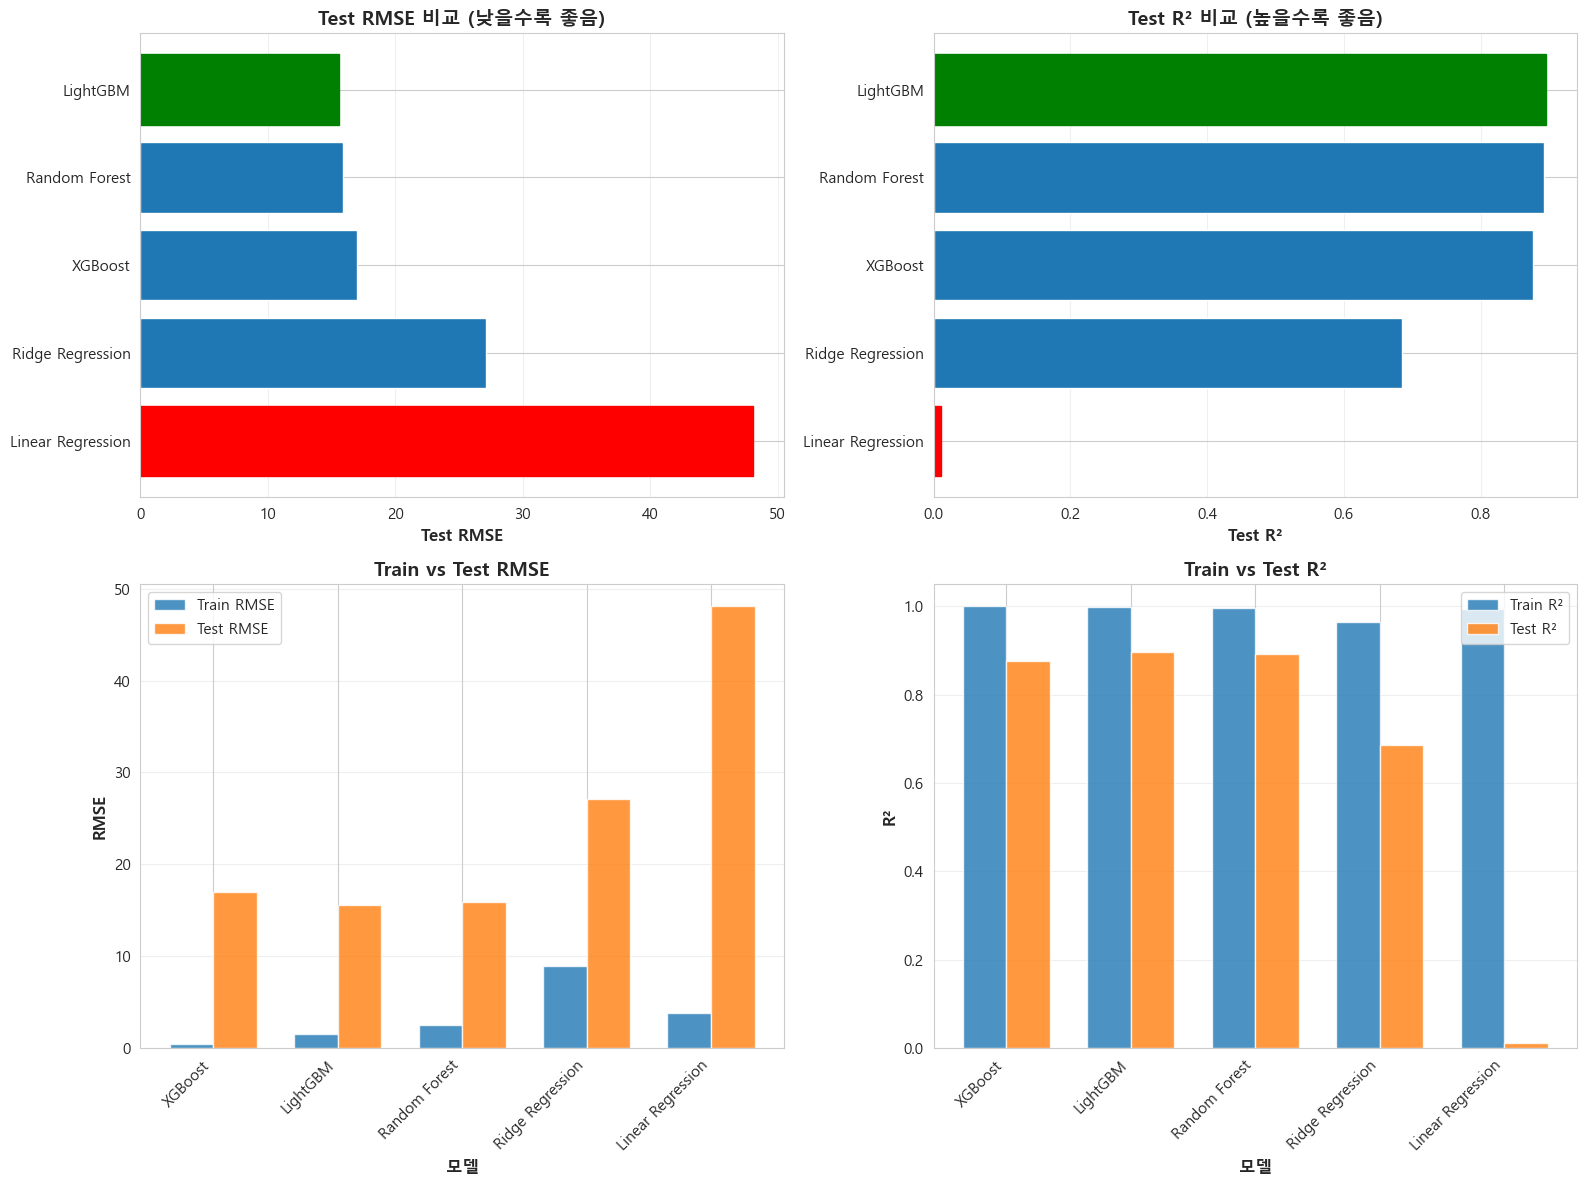

In [13]:
# 모델 성능 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Test RMSE 비교
ax = axes[0, 0]
results_df_sorted = results_df.sort_values('Test_RMSE', ascending=False)
bars = ax.barh(results_df_sorted['Model'], results_df_sorted['Test_RMSE'])
bars[0].set_color('red')
bars[-1].set_color('green')
ax.set_xlabel('Test RMSE', fontsize=12, fontweight='bold')
ax.set_title('Test RMSE 비교 (낮을수록 좋음)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# 2. Test R² 비교
ax = axes[0, 1]
results_df_sorted = results_df.sort_values('Test_R2')
bars = ax.barh(results_df_sorted['Model'], results_df_sorted['Test_R2'])
bars[0].set_color('red')
bars[-1].set_color('green')
ax.set_xlabel('Test R²', fontsize=12, fontweight='bold')
ax.set_title('Test R² 비교 (높을수록 좋음)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# 3. Train vs Test RMSE
ax = axes[1, 0]
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width/2, results_df['Train_RMSE'], width, label='Train RMSE', alpha=0.8)
ax.bar(x + width/2, results_df['Test_RMSE'], width, label='Test RMSE', alpha=0.8)
ax.set_xlabel('모델', fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE', fontsize=12, fontweight='bold')
ax.set_title('Train vs Test RMSE', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 4. Train vs Test R²
ax = axes[1, 1]
ax.bar(x - width/2, results_df['Train_R2'], width, label='Train R²', alpha=0.8)
ax.bar(x + width/2, results_df['Test_R2'], width, label='Test R²', alpha=0.8)
ax.set_xlabel('모델', fontsize=12, fontweight='bold')
ax.set_ylabel('R²', fontsize=12, fontweight='bold')
ax.set_title('Train vs Test R²', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# 모델 평가 및 베스트 모델 선택 (수정 버전)
# ============================================================
print("="*80)
print(" 모델 평가 및 베스트 모델 선택")
print("="*80)

# 결과 데이터프레임 (변수명 수정: results_list → model_results)
results_df = pd.DataFrame(model_results)

# model_object 컬럼 추가 (모델 딕셔너리에서 가져오기)
results_df['model_object'] = results_df['Model'].map(models)

print(f"\n전체 모델 수: {len(results_df)}")

# --------------------------------------------------
# Step 1: CV 실패 모델 필터링
# --------------------------------------------------
valid_models = results_df[results_df['CV_R2'] > 0].copy()
invalid_models = results_df[results_df['CV_R2'] <= 0].copy()

if len(invalid_models) > 0:
    print(f"\n  CV 실패 모델 (자동 제외):")
    print("-"*80)
    for idx, row in invalid_models.iterrows():
        print(f"  • {row['Model']:20s}: CV R² = {row['CV_R2']:.4f}, CV RMSE = {row['CV_RMSE']:.4f}")
    print(f"\n→ {len(invalid_models)}개 모델이 CV 실패로 제외됨")

if len(valid_models) == 0:
    print("\n 모든 모델이 CV 실패, 전체 결과 사용 (주의 필요)")
    valid_models = results_df.copy()
else:
    print(f"\n 유효한 모델: {len(valid_models)}개")

# --------------------------------------------------
# Step 2: 종합 점수 계산
# --------------------------------------------------
# CV 70% + Test 30% (CV를 더 중요하게)
valid_models['Combined_Score'] = (
    0.7 * valid_models['CV_R2'] + 
    0.3 * valid_models['Test_R2']
)

# Test RMSE도 고려 (낮을수록 좋음)
valid_models['RMSE_Score'] = 1 / (valid_models['Test_RMSE'] + 1)

# 최종 점수
valid_models['Final_Score'] = (
    0.8 * valid_models['Combined_Score'] + 
    0.2 * valid_models['RMSE_Score']
)

# 정렬
valid_models = valid_models.sort_values('Final_Score', ascending=False)

# --------------------------------------------------
# Step 3: 베스트 모델 선정
# --------------------------------------------------
best_idx = valid_models.index[0]
best_model_name = valid_models.loc[best_idx, 'Model']
best_model = valid_models.loc[best_idx, 'model_object']

print(f"\n{'='*80}")
print(f" 베스트 모델 선정")
print(f"{'='*80}")
print(f"\n선정 기준: Combined Score (CV 70% + Test 30%)")
print(f"\n 베스트 모델: {best_model_name}")
print("-"*80)
print(f"  CV R²:          {valid_models.loc[best_idx, 'CV_R2']:.4f}")
print(f"  CV RMSE:        {valid_models.loc[best_idx, 'CV_RMSE']:.4f}")
print(f"  Test R²:        {valid_models.loc[best_idx, 'Test_R2']:.4f}")
print(f"  Test RMSE:      {valid_models.loc[best_idx, 'Test_RMSE']:.4f}")
print(f"  Combined Score: {valid_models.loc[best_idx, 'Combined_Score']:.4f}")
print("="*80)

# --------------------------------------------------
# Step 4: 상위 모델 비교
# --------------------------------------------------
print(f"\n 상위 {min(5, len(valid_models))}개 모델 비교:")
print("-"*80)
print(f"{'순위':<4} {'모델':<20} {'CV R²':<10} {'Test R²':<10} {'Test RMSE':<12} {'종합':<10}")
print("-"*80)

for rank, (idx, row) in enumerate(valid_models.head(5).iterrows(), 1):
    print(f"{rank:<4} {row['Model']:<20} {row['CV_R2']:<10.4f} {row['Test_R2']:<10.4f} "
          f"{row['Test_RMSE']:<12.4f} {row['Combined_Score']:<10.4f}")

print("-"*80)

# --------------------------------------------------
# Step 5: 베스트 모델로 예측
# --------------------------------------------------
# Scaling 필요 여부 확인
if best_model_name in models_need_scaling:
    scaler = scalers[best_model_name]
    X_train_eval = scaler.transform(X_train)
    X_test_eval = scaler.transform(X_test)
    y_pred_train_best = best_model.predict(X_train_eval)
    y_pred_test_best = best_model.predict(X_test_eval)
else:
    y_pred_train_best = best_model.predict(X_train)
    y_pred_test_best = best_model.predict(X_test)

print(f"\n {best_model_name} 모델 선택 완료")

# 성능 검증
train_r2_best = r2_score(y_train, y_pred_train_best)
test_r2_best = r2_score(y_test, y_pred_test_best)
train_rmse_best = np.sqrt(mean_squared_error(y_train, y_pred_train_best))
test_rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_test_best))

print(f"\n최종 성능:")
print(f"  Train R²:   {train_r2_best:.4f}")
print(f"  Train RMSE: {train_rmse_best:.4f}")
print(f"  Test R²:    {test_r2_best:.4f}")
print(f"  Test RMSE:  {test_rmse_best:.4f}")

# Over-fitting 체크
gap = train_rmse_best - test_rmse_best
if abs(gap) < 5:
    print(f"\n 일반화 양호 (Train-Test RMSE 차이: {gap:.2f})")
elif gap > 10:
    print(f"\n  과적합 가능성 (Train-Test RMSE 차이: {gap:.2f})")
elif gap < -10:
    print(f"\n  Test가 너무 쉬움 (Train-Test RMSE 차이: {gap:.2f})")

 모델 평가 및 베스트 모델 선택

전체 모델 수: 5

  CV 실패 모델 (자동 제외):
--------------------------------------------------------------------------------
  • Linear Regression   : CV R² = -4.4655, CV RMSE = 90.0087

→ 1개 모델이 CV 실패로 제외됨

 유효한 모델: 4개

 베스트 모델 선정

선정 기준: Combined Score (CV 70% + Test 30%)

 베스트 모델: LightGBM
--------------------------------------------------------------------------------
  CV R²:          0.1766
  CV RMSE:        32.6551
  Test R²:        0.8963
  Test RMSE:      15.5783
  Combined Score: 0.3925

 상위 4개 모델 비교:
--------------------------------------------------------------------------------
순위   모델                   CV R²      Test R²    Test RMSE    종합        
--------------------------------------------------------------------------------
1    LightGBM             0.1766     0.8963     15.5783      0.3925    
2    Ridge Regression     0.2385     0.6857     27.1146      0.3727    
3    XGBoost              0.1285     0.8767     16.9798      0.3530    
4    Random Forest       

 Feature Importance - 모든 모델 호환

Feature Importance (LightGBM)
--------------------------------------------------------------------------------
방법: Built-in Feature Importances (Gini Importance)

상위 30개 중요 Feature:
--------------------------------------------------------------------------------
순위   Feature                                  중요도          백분율       
--------------------------------------------------------------------------------
1    dis_time_roll_mean5                      738.000000     7.99%
2    dis_time                                 546.000000     5.91%
3    cha_time_roll_mean5                      409.000000     4.43%
4    dis_V_mean                               392.000000     4.24%
5    imp2_Battery_impedance_mag_norm          347.000000     3.76%
6    dis_I_mean                               299.000000     3.24%
7    imp_Re_roll_mean5                        278.000000     3.01%
8    imp_Rct_roll_mean5                       237.000000     2.57%
9    dis_dV_dQ_ear

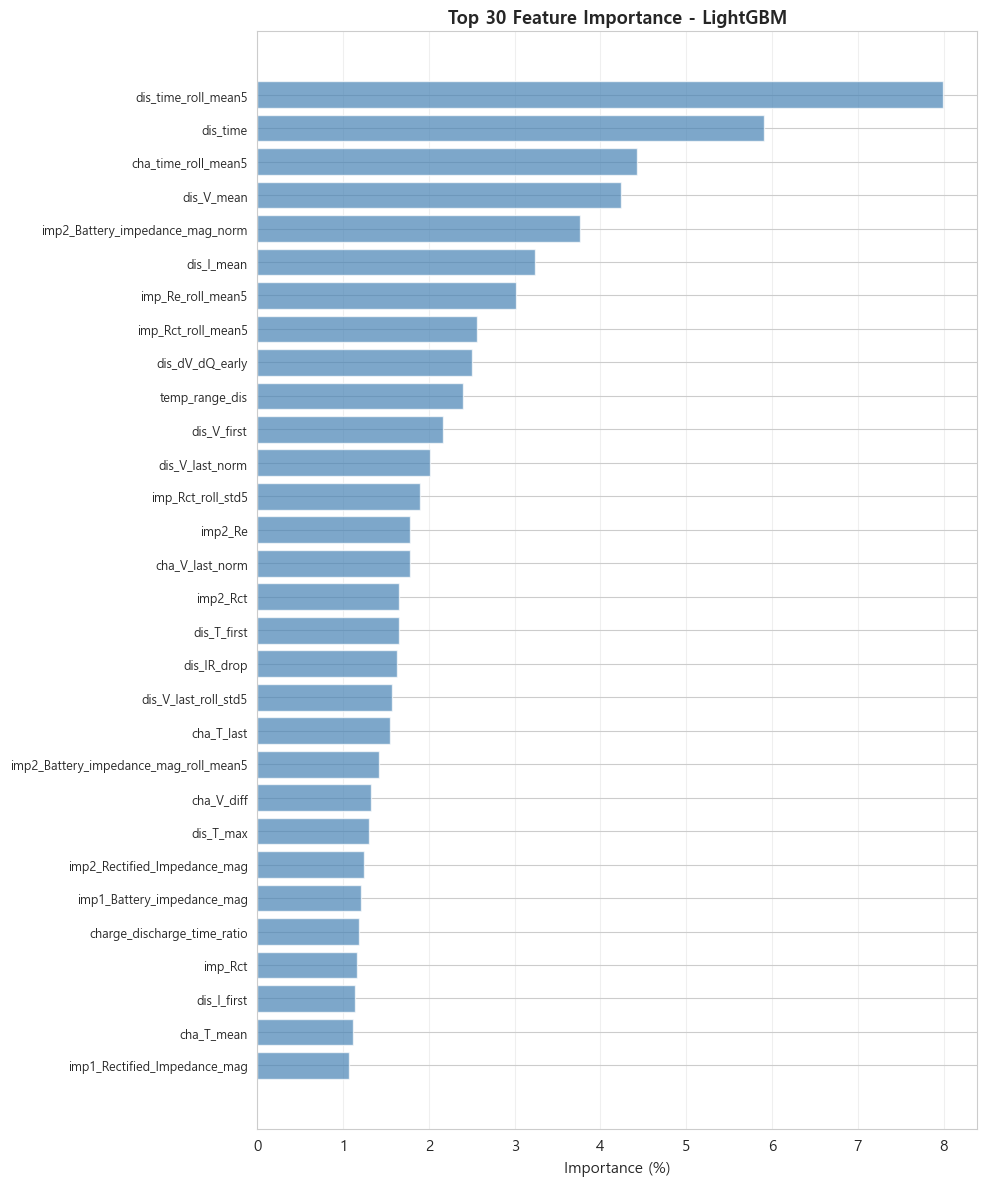


 Feature Importance 분석 완료


In [15]:
# ============================================================
# Feature Importance 분석
# ============================================================
print("="*80)
print(" Feature Importance - 모든 모델 호환")
print("="*80)

from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# --------------------------------------------------
# Feature Importance 계산
# --------------------------------------------------
print(f"\nFeature Importance ({best_model_name})")
print("-"*80)

if hasattr(best_model, 'feature_importances_'):
    # Tree 기반 모델
    print("방법: Built-in Feature Importances (Gini Importance)")
    importances = best_model.feature_importances_
    feature_names = X_train.columns
    
else:
    # Linear 모델 등 - Permutation Importance
    print("방법: Permutation Importance")
    print("(각 변수를 섞었을 때 성능 저하 정도)")
    
    perm_result = permutation_importance(
        best_model, X_test, y_test,
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )
    
    importances = perm_result.importances_mean
    feature_names = X_test.columns

# --------------------------------------------------
# 정규화 (백분율로)
# --------------------------------------------------
importances_pct = (importances / importances.sum()) * 100

# DataFrame 생성
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances,
    'Importance_Pct': importances_pct
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# --------------------------------------------------
# 상위 30개 출력
# --------------------------------------------------
print(f"\n상위 30개 중요 Feature:")
print("-"*80)
print(f"{'순위':<4} {'Feature':<40} {'중요도':<12} {'백분율':<10}")
print("-"*80)

for idx, row in importance_df.head(30).iterrows():
    print(f"{idx+1:<4} {row['Feature']:<40} {row['Importance']:<12.6f} {row['Importance_Pct']:>6.2f}%")

print("-"*80)

# --------------------------------------------------
# 요청 변수 확인
# --------------------------------------------------
print(f"\n 요청된 중요 변수의 순위:")
print("-"*80)

important_vars = [
    'dis_Capacity', 'dis_Capacity_norm', 'capacity_retention',
    'imp_Re', 'imp_Rct', 'imp2_Battery_impedance_mag_norm',
    'dis_IR_drop', 'dis_dV_dQ_early',
    'dis_time', 'cha_time', 'cha_ratio_cc',
    'global_cycle', 'dis_T_max', 'cha_T_max',
]

for var in important_vars:
    # 원본 또는 파생 변수 찾기
    matches = importance_df[importance_df['Feature'].str.contains(var, case=False, na=False)]
    
    if len(matches) > 0:
        best_match = matches.iloc[0]
        rank = importance_df[importance_df['Feature'] == best_match['Feature']].index[0] + 1
        print(f"  {var:30s} → {best_match['Feature']:40s} {rank:3d}위 ({best_match['Importance_Pct']:5.2f}%)")
    else:
        print(f"  {var:30s} → (상위 30개 밖)")

# --------------------------------------------------
# 시각화
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 12))

top_n = min(30, len(importance_df))
top_features = importance_df.head(top_n)

ax.barh(range(top_n), top_features['Importance_Pct'], alpha=0.7, color='steelblue')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['Feature'], fontsize=9)
ax.set_xlabel('Importance (%)', fontsize=11)
ax.set_title(f'Top {top_n} Feature Importance - {best_model_name}', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Feature Importance 분석 완료")

 Cross-Validation 예측값 생성
  Fold 1: 167개 샘플
  Fold 2: 167개 샘플
  Fold 3: 132개 샘플

 CV 예측값 생성 완료: 466개
   CV R²:   0.4427
   CV RMSE: 35.0136

 성능 시각화


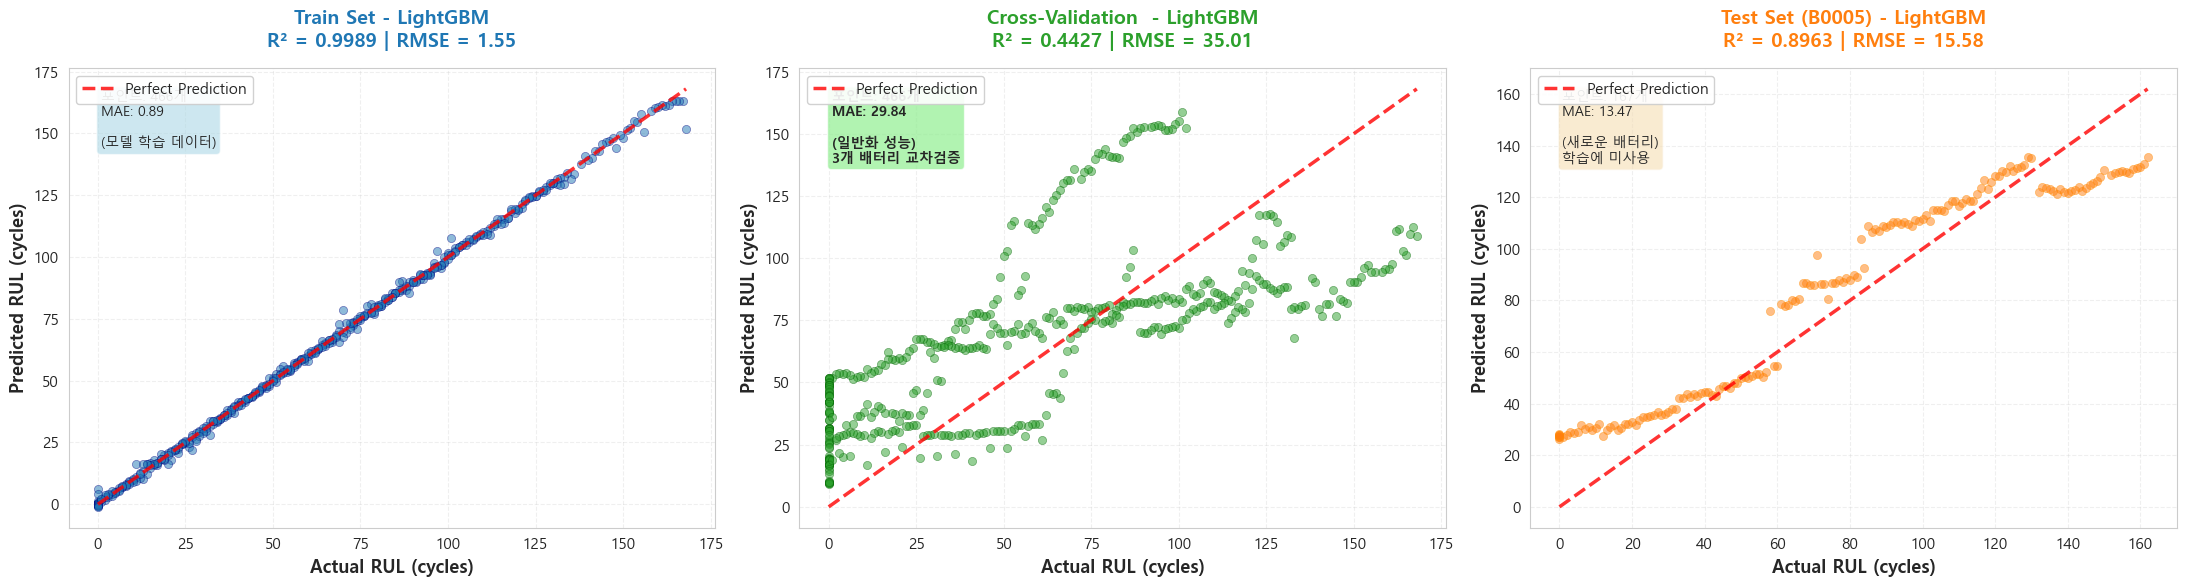


 시각화 완료


In [16]:
# ============================================================
# CV 예측값 생성 (시각화용)
# ============================================================
print("="*80)
print(" Cross-Validation 예측값 생성")
print("="*80)

cv_actuals = []
cv_predictions = []

# 베스트 모델로 CV 재수행
logo = LeaveOneGroupOut()

for fold_idx, (train_idx, valid_idx) in enumerate(logo.split(X_train, y_train, train_groups), 1):
    X_tr = X_train.iloc[train_idx].copy()
    X_va = X_train.iloc[valid_idx].copy()
    y_tr = y_train.iloc[train_idx]
    y_va = y_train.iloc[valid_idx]
    
    # Scaling 필요 여부 확인
    if best_model_name in models_need_scaling:
        scaler_cv = StandardScaler()
        X_tr = scaler_cv.fit_transform(X_tr)
        X_va = scaler_cv.transform(X_va)
    
    # 베스트 모델과 동일한 하이퍼파라미터로 학습
    if best_model_name == 'Random Forest':
        model_cv = RandomForestRegressor(**best_model.get_params())
    elif best_model_name == 'XGBoost':
        model_cv = xgb.XGBRegressor(**best_model.get_params())
    elif best_model_name == 'LightGBM':
        model_cv = LGBMRegressor(**best_model.get_params())
    elif best_model_name == 'Ridge Regression':
        model_cv = Ridge(**best_model.get_params())
    elif best_model_name == 'Linear Regression':
        model_cv = LinearRegression()
    
    model_cv.fit(X_tr, y_tr)
    pred_va = model_cv.predict(X_va)
    
    cv_actuals.extend(y_va.values)
    cv_predictions.extend(pred_va)
    
    print(f"  Fold {fold_idx}: {len(y_va)}개 샘플")

cv_actuals = np.array(cv_actuals)
cv_predictions = np.array(cv_predictions)

# CV 성능 재계산
cv_r2 = r2_score(cv_actuals, cv_predictions)
cv_rmse = np.sqrt(mean_squared_error(cv_actuals, cv_predictions))
cv_mae = mean_absolute_error(cv_actuals, cv_predictions)

print(f"\n CV 예측값 생성 완료: {len(cv_predictions)}개")
print(f"   CV R²:   {cv_r2:.4f}")
print(f"   CV RMSE: {cv_rmse:.4f}")

# ============================================================
# Train / CV / Test 성능 시각화
# ============================================================
print("\n" + "="*80)
print(" 성능 시각화")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# ------------------------------------------------------------
# 1. Train Set
# ------------------------------------------------------------
ax1 = axes[0]
ax1.scatter(y_train, y_pred_train_best, alpha=0.5, s=35, 
           c='#1f77b4', edgecolors='navy', linewidth=0.5)
ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 
         'r--', lw=2.5, label='Perfect Prediction', alpha=0.8)
ax1.set_xlabel('Actual RUL (cycles)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Predicted RUL (cycles)', fontsize=13, fontweight='bold')
ax1.set_title(f'Train Set - {best_model_name}\nR² = {train_r2_best:.4f} | RMSE = {train_rmse_best:.2f}', 
              fontsize=14, fontweight='bold', color='#1f77b4', pad=15)
ax1.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax1.grid(alpha=0.3, linestyle='--')

# 정보 박스
train_mae_best = mean_absolute_error(y_train, y_pred_train_best)
textstr = f'포인트: {len(y_train):,}개\nMAE: {train_mae_best:.2f}\n\n(모델 학습 데이터)'
props = dict(boxstyle='round', facecolor='lightblue', alpha=0.6)
ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

# ------------------------------------------------------------
# 2. Cross-Validation (핵심 지표!)
# ------------------------------------------------------------
ax2 = axes[1]
ax2.scatter(cv_actuals, cv_predictions, alpha=0.5, s=35, 
           c='#2ca02c', edgecolors='darkgreen', linewidth=0.5)
ax2.plot([cv_actuals.min(), cv_actuals.max()], 
         [cv_actuals.min(), cv_actuals.max()], 
         'r--', lw=2.5, label='Perfect Prediction', alpha=0.8)
ax2.set_xlabel('Actual RUL (cycles)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Predicted RUL (cycles)', fontsize=13, fontweight='bold')
ax2.set_title(f'Cross-Validation  - {best_model_name}\nR² = {cv_r2:.4f} | RMSE = {cv_rmse:.2f}', 
              fontsize=14, fontweight='bold', color='#2ca02c', pad=15)
ax2.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax2.grid(alpha=0.3, linestyle='--')

# 정보 박스
textstr = f'포인트: {len(cv_predictions):,}개\nMAE: {cv_mae:.2f}\n\n(일반화 성능)\n3개 배터리 교차검증'
props = dict(boxstyle='round', facecolor='lightgreen', alpha=0.7)
ax2.text(0.05, 0.95, textstr, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', bbox=props, weight='bold')

# ------------------------------------------------------------
# 3. Test Set (B0005)
# ------------------------------------------------------------
ax3 = axes[2]
ax3.scatter(y_test, y_pred_test_best, alpha=0.5, s=35, 
           c='#ff7f0e', edgecolors='darkorange', linewidth=0.5)
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2.5, label='Perfect Prediction', alpha=0.8)
ax3.set_xlabel('Actual RUL (cycles)', fontsize=13, fontweight='bold')
ax3.set_ylabel('Predicted RUL (cycles)', fontsize=13, fontweight='bold')
ax3.set_title(f'Test Set (B0005) - {best_model_name}\nR² = {test_r2_best:.4f} | RMSE = {test_rmse_best:.2f}', 
              fontsize=14, fontweight='bold', color='#ff7f0e', pad=15)
ax3.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax3.grid(alpha=0.3, linestyle='--')

# 정보 박스
test_mae_best = mean_absolute_error(y_test, y_pred_test_best)
textstr = f'포인트: {len(y_test):,}개\nMAE: {test_mae_best:.2f}\n\n(새로운 배터리)\n학습에 미사용'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.6)
ax3.text(0.05, 0.95, textstr, transform=ax3.transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print(" 시각화 완료")
print("="*80)

 Cross-Validation 예측값 생성
  Fold 1 (B0006): 167개 샘플
  Fold 2 (B0007): 167개 샘플
  Fold 3 (B0018): 132개 샘플

 CV 예측값 생성 완료: 466개
   CV R²:   0.4427
   CV RMSE: 35.0136
   CV MAE:  29.8367

 배터리별 CV 예측 성능

배터리별 성능:
--------------------------------------------------------------------------------
Battery  Points        R²      RMSE       MAE
  B0006     167 -0.727612 44.385058 41.753870
  B0007     167  0.516385 33.777904 28.077602
  B0018     132  0.741088 19.802233 16.985119
--------------------------------------------------------------------------------

 통계 요약:
  평균 R²:   0.1766
  R² 범위:   -0.7276 ~ 0.7411
  평균 RMSE: 32.66
  RMSE 범위: 19.80 ~ 44.39


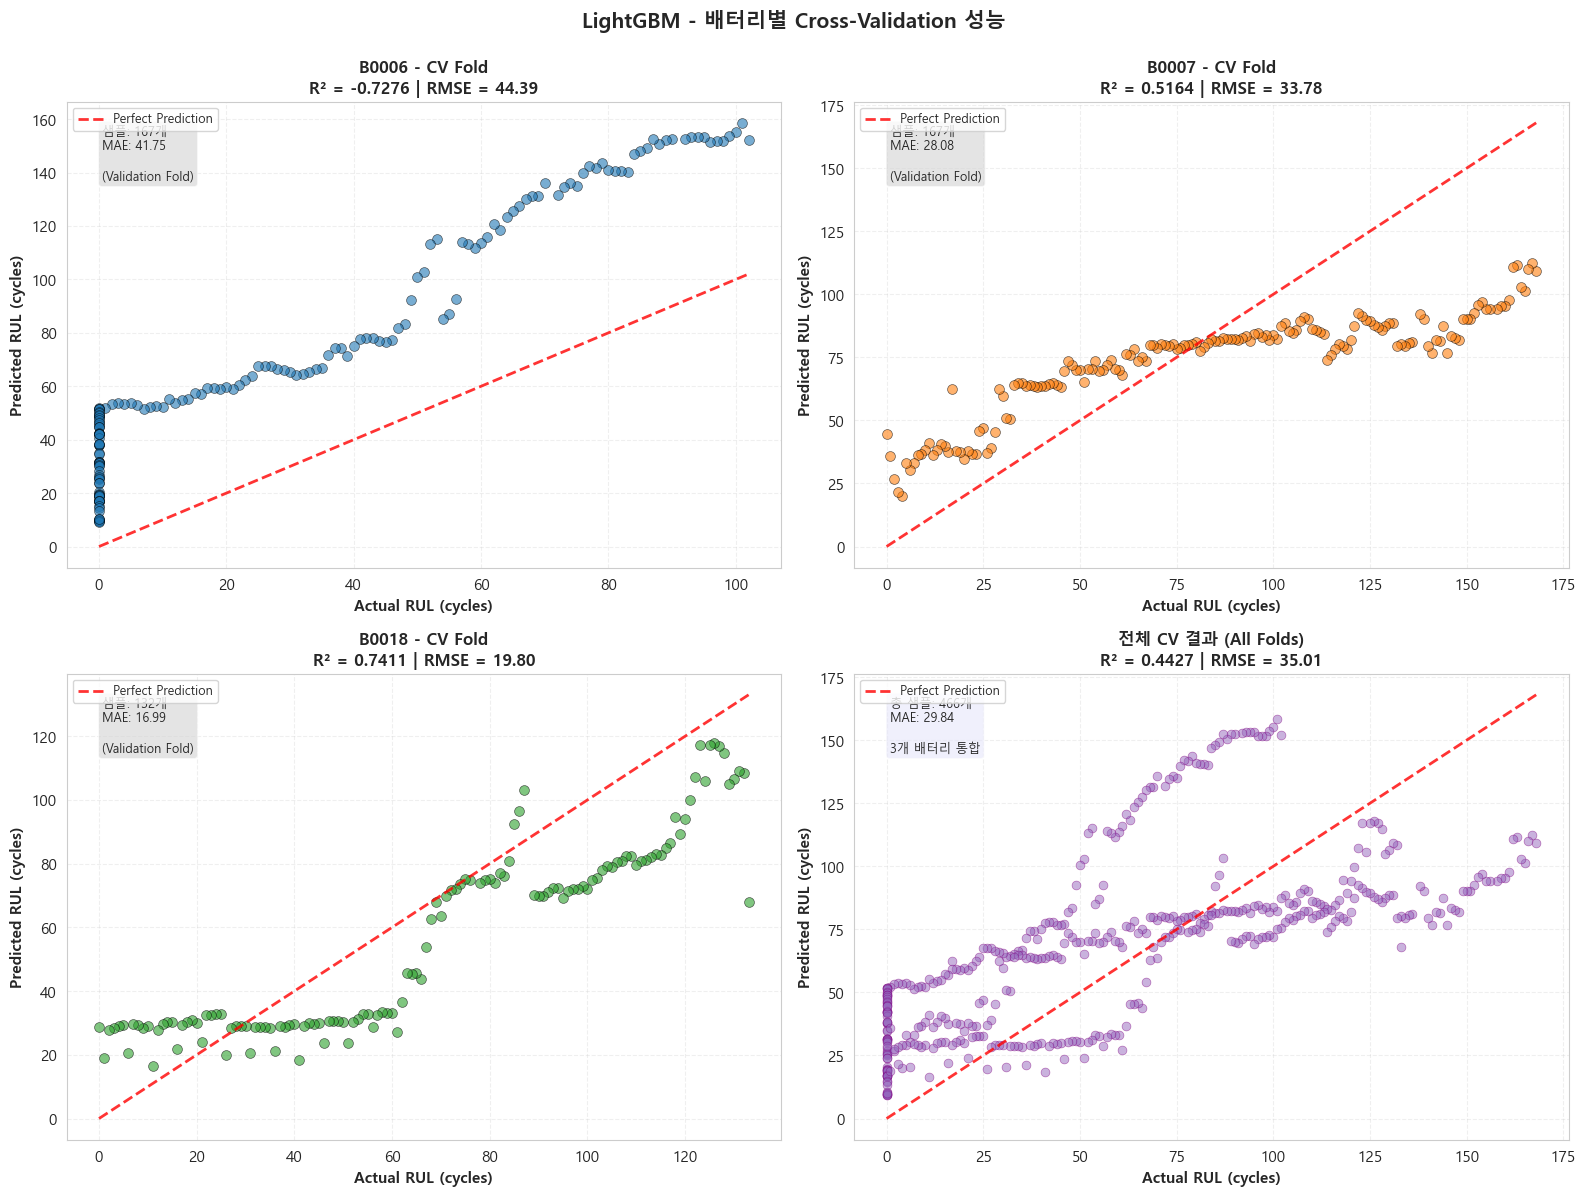


 배터리별 분석 완료


In [17]:
# ============================================================
# CV 예측값 생성 (배터리 ID, Cycle 정보 포함)
# ============================================================
print("="*80)
print(" Cross-Validation 예측값 생성")
print("="*80)

cv_actuals = []
cv_predictions = []
cv_battery_ids = []
cv_cycles = []

# 베스트 모델로 CV 재수행
logo = LeaveOneGroupOut()

for fold_idx, (train_idx, valid_idx) in enumerate(logo.split(X_train, y_train, train_groups), 1):
    X_tr = X_train.iloc[train_idx].copy()
    X_va = X_train.iloc[valid_idx].copy()
    y_tr = y_train.iloc[train_idx]
    y_va = y_train.iloc[valid_idx]
    
    # 배터리 ID와 cycle 정보 저장
    battery_ids_va = df_selected.loc[train_mask].iloc[valid_idx]['battery_id'].values
    cycles_va = df_selected.loc[train_mask].iloc[valid_idx]['global_cycle'].values
    
    # Scaling 필요 여부 확인
    if best_model_name in models_need_scaling:
        scaler_cv = StandardScaler()
        X_tr = scaler_cv.fit_transform(X_tr)
        X_va = scaler_cv.transform(X_va)
    
    # 베스트 모델과 동일한 하이퍼파라미터로 학습
    if best_model_name == 'Random Forest':
        model_cv = RandomForestRegressor(**best_model.get_params())
    elif best_model_name == 'XGBoost':
        model_cv = xgb.XGBRegressor(**best_model.get_params())
    elif best_model_name == 'LightGBM':
        model_cv = LGBMRegressor(**best_model.get_params())
    elif best_model_name == 'Ridge Regression':
        model_cv = Ridge(**best_model.get_params())
    elif best_model_name == 'Linear Regression':
        model_cv = LinearRegression()
    
    model_cv.fit(X_tr, y_tr)
    pred_va = model_cv.predict(X_va)
    
    # 결과 저장
    cv_actuals.extend(y_va.values)
    cv_predictions.extend(pred_va)
    cv_battery_ids.extend(battery_ids_va)
    cv_cycles.extend(cycles_va)
    
    # Fold 정보 출력
    unique_battery = np.unique(battery_ids_va)[0]
    print(f"  Fold {fold_idx} ({unique_battery}): {len(y_va)}개 샘플")

cv_actuals = np.array(cv_actuals)
cv_predictions = np.array(cv_predictions)
cv_battery_ids = np.array(cv_battery_ids)
cv_cycles = np.array(cv_cycles)

# CV 성능 재계산
cv_r2 = r2_score(cv_actuals, cv_predictions)
cv_rmse = np.sqrt(mean_squared_error(cv_actuals, cv_predictions))
cv_mae = mean_absolute_error(cv_actuals, cv_predictions)

print(f"\n CV 예측값 생성 완료: {len(cv_predictions)}개")
print(f"   CV R²:   {cv_r2:.4f}")
print(f"   CV RMSE: {cv_rmse:.4f}")
print(f"   CV MAE:  {cv_mae:.4f}")

# ============================================================
# 배터리별 Cross-Validation 성능 분석
# ============================================================
print("\n" + "="*80)
print(" 배터리별 CV 예측 성능")
print("="*80)

# CV 결과를 DataFrame으로 변환
cv_results_df = pd.DataFrame({
    'battery_id': cv_battery_ids,
    'global_cycle': cv_cycles,
    'actual_RUL': cv_actuals,
    'predicted_RUL': cv_predictions
})

# 배터리별 성능 계산
battery_cv_performance = []

for battery in train_batteries:
    battery_mask = cv_results_df['battery_id'] == battery
    battery_data = cv_results_df[battery_mask]
    
    if len(battery_data) > 0:
        battery_rmse = np.sqrt(mean_squared_error(
            battery_data['actual_RUL'], 
            battery_data['predicted_RUL']
        ))
        battery_r2 = r2_score(
            battery_data['actual_RUL'], 
            battery_data['predicted_RUL']
        )
        battery_mae = mean_absolute_error(
            battery_data['actual_RUL'], 
            battery_data['predicted_RUL']
        )
        
        battery_cv_performance.append({
            'Battery': battery,
            'Points': len(battery_data),
            'R²': battery_r2,
            'RMSE': battery_rmse,
            'MAE': battery_mae
        })

battery_cv_df = pd.DataFrame(battery_cv_performance)

print("\n배터리별 성능:")
print("-"*80)
print(battery_cv_df.to_string(index=False))
print("-"*80)

# 배터리별 성능 통계
print(f"\n 통계 요약:")
print(f"  평균 R²:   {battery_cv_df['R²'].mean():.4f}")
print(f"  R² 범위:   {battery_cv_df['R²'].min():.4f} ~ {battery_cv_df['R²'].max():.4f}")
print(f"  평균 RMSE: {battery_cv_df['RMSE'].mean():.2f}")
print(f"  RMSE 범위: {battery_cv_df['RMSE'].min():.2f} ~ {battery_cv_df['RMSE'].max():.2f}")

print("="*80)

# ============================================================
# 배터리별 시각화
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, battery in enumerate(train_batteries):
    ax = axes[idx // 2, idx % 2]
    battery_mask = cv_results_df['battery_id'] == battery
    battery_data = cv_results_df[battery_mask]
    
    if len(battery_data) > 0:
        battery_r2 = r2_score(battery_data['actual_RUL'], battery_data['predicted_RUL'])
        battery_rmse = np.sqrt(mean_squared_error(battery_data['actual_RUL'], battery_data['predicted_RUL']))
        battery_mae = mean_absolute_error(battery_data['actual_RUL'], battery_data['predicted_RUL'])
        
        # 색상 선택
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
        color = colors[idx]
        
        ax.scatter(battery_data['actual_RUL'], battery_data['predicted_RUL'], 
                   alpha=0.6, s=50, c=color, edgecolors='black', linewidth=0.5)
        ax.plot([battery_data['actual_RUL'].min(), battery_data['actual_RUL'].max()], 
                [battery_data['actual_RUL'].min(), battery_data['actual_RUL'].max()], 
                'r--', lw=2, alpha=0.8, label='Perfect Prediction')
        
        ax.set_xlabel('Actual RUL (cycles)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Predicted RUL (cycles)', fontsize=11, fontweight='bold')
        ax.set_title(f'{battery} - CV Fold\nR² = {battery_r2:.4f} | RMSE = {battery_rmse:.2f}', 
                     fontsize=12, fontweight='bold')
        ax.legend(loc='upper left', fontsize=9)
        ax.grid(alpha=0.3, linestyle='--')
        
        # 통계 박스
        textstr = f'샘플: {len(battery_data)}개\nMAE: {battery_mae:.2f}\n\n(Validation Fold)'
        props = dict(boxstyle='round', facecolor='lightgray', alpha=0.6)
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=9,
                verticalalignment='top', bbox=props)

# 4번째 subplot (비어있음) - 전체 CV 결과
ax4 = axes[1, 1]
ax4.scatter(cv_actuals, cv_predictions, alpha=0.5, s=40, 
           c='#9467bd', edgecolors='purple', linewidth=0.5)
ax4.plot([cv_actuals.min(), cv_actuals.max()], 
         [cv_actuals.min(), cv_actuals.max()], 
         'r--', lw=2, alpha=0.8, label='Perfect Prediction')
ax4.set_xlabel('Actual RUL (cycles)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Predicted RUL (cycles)', fontsize=11, fontweight='bold')
ax4.set_title(f'전체 CV 결과 (All Folds)\nR² = {cv_r2:.4f} | RMSE = {cv_rmse:.2f}', 
             fontsize=12, fontweight='bold')
ax4.legend(loc='upper left', fontsize=9)
ax4.grid(alpha=0.3, linestyle='--')

# 통계 박스
textstr = f'총 샘플: {len(cv_actuals)}개\nMAE: {cv_mae:.2f}\n\n3개 배터리 통합'
props = dict(boxstyle='round', facecolor='lavender', alpha=0.6)
ax4.text(0.05, 0.95, textstr, transform=ax4.transAxes, fontsize=9,
         verticalalignment='top', bbox=props)

plt.suptitle(f'{best_model_name} - 배터리별 Cross-Validation 성능', 
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n 배터리별 분석 완료")
print("="*80)

## 9. Feature Importance 분석

Feature Importance (LightGBM)

상위 20개 중요 Feature:
                        Feature  Importance
            dis_time_roll_mean5         738
                       dis_time         546
            cha_time_roll_mean5         409
                     dis_V_mean         392
imp2_Battery_impedance_mag_norm         347
                     dis_I_mean         299
              imp_Re_roll_mean5         278
             imp_Rct_roll_mean5         237
                dis_dV_dQ_early         231
                 temp_range_dis         221
                    dis_V_first         200
                dis_V_last_norm         186
              imp_Rct_roll_std5         175
                        imp2_Re         164
                cha_V_last_norm         164
                       imp2_Rct         153
                    dis_T_first         152
                    dis_IR_drop         150
           dis_V_last_roll_std5         145
                     cha_T_last         143


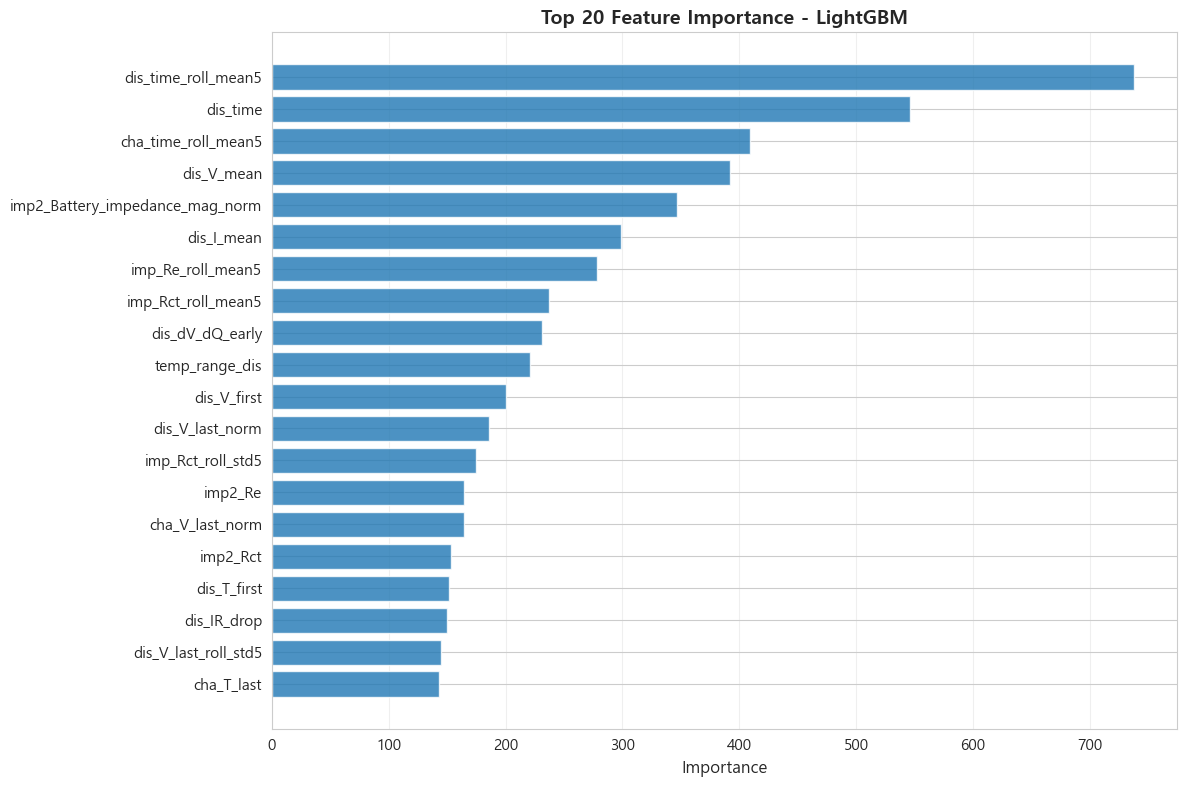

In [18]:
# Tree-based 모델만 Feature Importance 제공

if best_model_name in ['Random Forest', 'XGBoost', 'LightGBM']:
    print("="*80)
    print(f"Feature Importance ({best_model_name})")
    print("="*80)
    
    if hasattr(best_model, 'feature_importances_'):
        importances = best_model.feature_importances_
        feature_names = X_train.columns

        # 길이 불일치 방지
        if len(importances) != len(feature_names):
            min_len = min(len(importances), len(feature_names))
            print(f" 중요도 길이({len(importances)})와 피처 수({len(feature_names)})가 달라 앞 {min_len}개만 사용.")
            importances = importances[:min_len]
            feature_names = feature_names[:min_len]

        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        }).sort_values('Importance', ascending=False).reset_index(drop=True)

        print("\n상위 20개 중요 Feature:")
        print(importance_df.head(20).to_string(index=False))

        fig, ax = plt.subplots(figsize=(12, 8))
        top_n = min(20, len(importance_df))
        top_features = importance_df.head(top_n)

        ax.barh(range(top_n), top_features['Importance'], alpha=0.8)
        ax.set_yticks(range(top_n))
        ax.set_yticklabels(top_features['Feature'])
        ax.set_xlabel('Importance', fontsize=12)
        ax.set_title(f'Top {top_n} Feature Importance - {best_model_name}', 
                     fontsize=14, fontweight='bold')
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3)

        plt.tight_layout()
        plt.show()
    else:
        print("이 모델은 feature_importances_ 속성이 없음.")
else:
    print("="*80)
    print(f"  {best_model_name}는 Feature Importance를 제공하지 않음.")
    print("="*80)


================================

## 10.  실시간 위험 배터리 탐지 시스템 (B0005 테스트 성능 중심)


In [19]:
print("="*80)
print(" 실시간 위험 배터리 탐지 시스템")
print("="*80)

# Train/Test 개별 예측 결과 정리
train_results = df_selected.loc[train_mask, ['battery_id', 'global_cycle', 'RUL']].copy().reset_index(drop=True)
train_results['dataset_role'] = 'TRAIN'
train_results['RUL_Predicted'] = y_pred_train_best
train_results['RUL_Error'] = np.abs(train_results['RUL'] - train_results['RUL_Predicted'])

test_results = df_selected.loc[test_mask, ['battery_id', 'global_cycle', 'RUL']].copy().reset_index(drop=True)
test_results['dataset_role'] = 'TEST'
test_results['RUL_Predicted'] = y_pred_test_best
test_results['RUL_Error'] = np.abs(test_results['RUL'] - test_results['RUL_Predicted'])

# SOH_target 등 부가 컬럼 병합
extra_cols = [c for c in ['SOH_target', 'dis_Capacity', 'dis_T_max', 'dis_V_last', 'cha_T_max', 'cha_V_last', 
                          'cha_time', 'dis_time', 'capacity_retention', 'soh_degradation_rate',
                          'voltage_efficiency', 'temp_efficiency'] if c in df_selected.columns]

train_results = pd.concat([train_results, df_selected.loc[train_mask, extra_cols].reset_index(drop=True)], axis=1)
test_results = pd.concat([test_results, df_selected.loc[test_mask, extra_cols].reset_index(drop=True)], axis=1)

# 전체 결과 결합
results_all = pd.concat([train_results, test_results], ignore_index=True)

# 위험도 분류 함수
def classify_risk(row):
    rul_pred = row['RUL_Predicted']
    soh = row['SOH_target'] if 'SOH_target' in row.index and pd.notnull(row['SOH_target']) else np.nan

    if rul_pred <= 10 or (pd.notnull(soh) and soh <= 70):
        return 'CRITICAL'
    elif rul_pred <= 30 or (pd.notnull(soh) and soh <= 80):
        return 'WARNING'
    elif rul_pred <= 60 or (pd.notnull(soh) and soh <= 90):
        return 'CAUTION'
    else:
        return 'NORMAL'

results_all['Risk_Level'] = results_all.apply(classify_risk, axis=1)

# 역할별 분리 저장
train_results = results_all[results_all['dataset_role'] == 'TRAIN'].copy()
test_results = results_all[results_all['dataset_role'] == 'TEST'].copy()

print("\n TEST 배터리(B0005) 위험도 분포:")
risk_dist_test = test_results['Risk_Level'].value_counts()
for level in ['CRITICAL', 'WARNING', 'CAUTION', 'NORMAL']:
    count = risk_dist_test.get(level, 0)
    pct = count / len(test_results) * 100 if len(test_results) > 0 else 0
    print(f"  {level:10s}: {count:4d}개 ({pct:5.2f}%)")

critical_test = test_results[test_results['Risk_Level'] == 'CRITICAL'].copy().sort_values('global_cycle')

print(f"\n B0005 CRITICAL 구간 수: {len(critical_test)}개")

if len(critical_test) > 0:
    show_cols = [c for c in ['battery_id', 'global_cycle', 'SOH_target', 'RUL', 'RUL_Predicted', 'RUL_Error', 'Risk_Level'] if c in critical_test.columns]
    print("\n[B0005 CRITICAL 상위 10행]")
    print(critical_test[show_cols].head(10).to_string(index=False))

# 후속 셀과 저장을 위해 df_selected를 결과 포함 버전으로 갱신
df_selected = results_all.copy()

 실시간 위험 배터리 탐지 시스템

 TEST 배터리(B0005) 위험도 분포:
  CRITICAL  :    5개 ( 2.99%)
  CAUTION   :   38개 (22.75%)
  NORMAL    :   63개 (37.72%)

 B0005 CRITICAL 구간 수: 5개

[B0005 CRITICAL 상위 10행]
battery_id  global_cycle  SOH_target  RUL  RUL_Predicted  RUL_Error Risk_Level
     B0005           163   69.910901    0      28.110977  28.110977   CRITICAL
     B0005           164   69.920943    0      27.766930  27.766930   CRITICAL
     B0005           165   69.672630    0      27.068647  27.068647   CRITICAL
     B0005           166   69.378514    0      26.890021  26.890021   CRITICAL
     B0005           167   69.348842    0      26.478631  26.478631   CRITICAL


## 10.5  운영 인사이트 및 수명 개선 시뮬레이션

이 섹션은 단순 예측을 넘어, **현재 상태 진단 → 교체 판단 → 개선 액션 제안**까지 연결.

핵심 질문은 세 가지.

1. **지금 상태라면 몇 회 정도 더 사용할 수 있는가?**
2. **교체는 언제 검토해야 하는가?**
3. **어떤 운영 변수를 어느 방향으로 조정하면 기대 수명이 얼마나 늘어날 수 있는가?**

> 아래 시뮬레이션은 **모델 기반 what-if 분석**
> 따라서 “반드시 이만큼 늘어난다”는 확정값이 아니라,  
> **현재 학습된 모델 기준 기대 개선 방향과 상대적 개선 폭**을 보여주는 참고 지표로 해석해야 함.

 Test 배터리 (B0005) 성능 분석


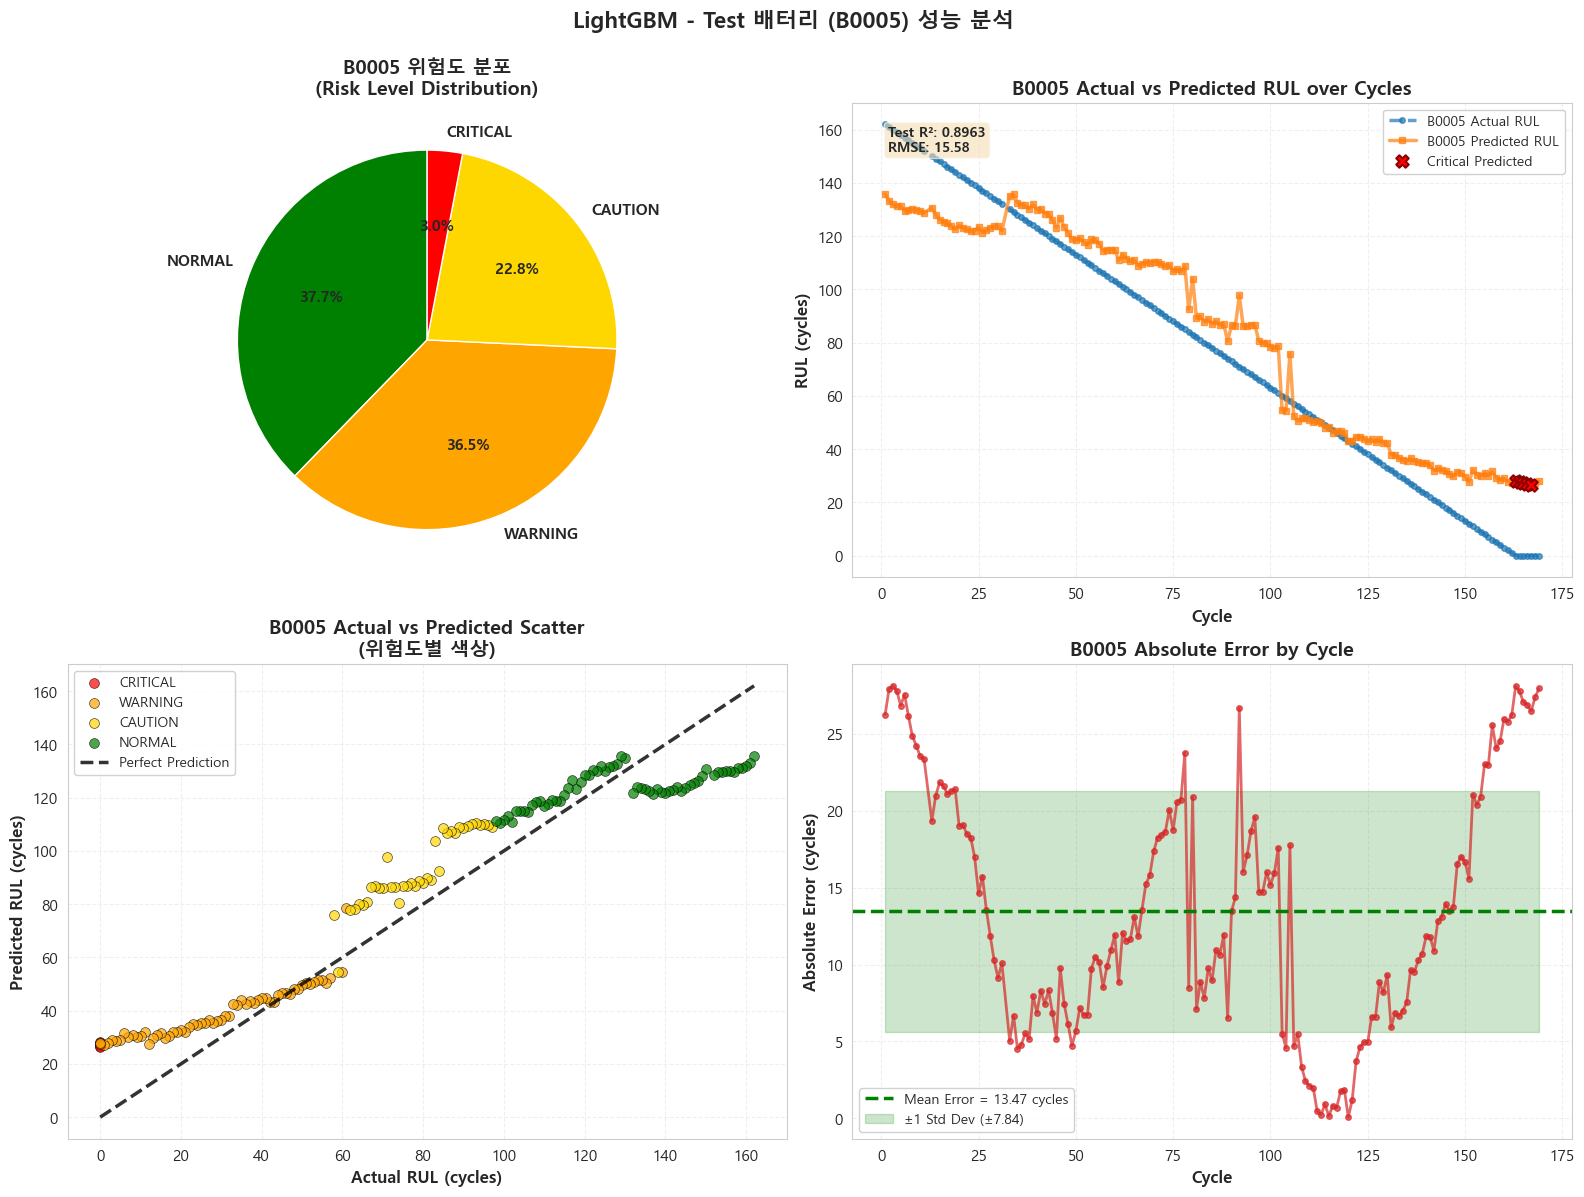


 B0005 성능 분석 완료


In [20]:
# ============================================================
# Battery Hold-out 시각화: B0005 성능 중심
# ============================================================
print("="*80)
print(f" Test 배터리 (B0005) 성능 분석")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = {'CRITICAL': 'red', 'WARNING': 'orange', 'CAUTION': 'gold', 'NORMAL': 'green'}

# ------------------------------------------------------------
# 1. B0005 위험도 분포
# ------------------------------------------------------------
ax1 = axes[0, 0]
risk_dist_test = test_results['Risk_Level'].value_counts()

if len(risk_dist_test) > 0:
    risk_colors = [colors[level] for level in risk_dist_test.index]
    ax1.pie(risk_dist_test.values, labels=risk_dist_test.index, autopct='%1.1f%%',
            startangle=90, colors=risk_colors, textprops={'fontsize': 11, 'weight': 'bold'})
    ax1.set_title('B0005 위험도 분포\n(Risk Level Distribution)', 
                  fontsize=14, fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'No Risk Data', ha='center', va='center', fontsize=12)
    ax1.set_title('B0005 위험도 분포', fontsize=14, fontweight='bold')

# ------------------------------------------------------------
# 2. B0005 Actual vs Predicted (핵심 그래프)
# ------------------------------------------------------------
ax2 = axes[0, 1]
b0005_plot = test_results.sort_values('global_cycle')

ax2.plot(b0005_plot['global_cycle'], b0005_plot['RUL'],
         linestyle='--', linewidth=2.5, label='B0005 Actual RUL', 
         color='#1f77b4', marker='o', markersize=4, alpha=0.7)
ax2.plot(b0005_plot['global_cycle'], b0005_plot['RUL_Predicted'],
         linewidth=2.5, label='B0005 Predicted RUL',
         color='#ff7f0e', marker='s', markersize=4, alpha=0.7)

# Critical 지점 강조
critical_mask = b0005_plot['Risk_Level'] == 'CRITICAL'
if critical_mask.any():
    ax2.scatter(b0005_plot.loc[critical_mask, 'global_cycle'],
                b0005_plot.loc[critical_mask, 'RUL_Predicted'],
                c='red', s=80, marker='X', zorder=5, 
                label='Critical Predicted', edgecolors='darkred', linewidth=1.5)

ax2.set_xlabel('Cycle', fontsize=12, fontweight='bold')
ax2.set_ylabel('RUL (cycles)', fontsize=12, fontweight='bold')
ax2.set_title('B0005 Actual vs Predicted RUL over Cycles', 
              fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10, framealpha=0.9)
ax2.grid(alpha=0.3, linestyle='--')

# 통계 박스
textstr = f'Test R²: {test_r2_best:.4f}\nRMSE: {test_rmse_best:.2f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.6)
ax2.text(0.05, 0.95, textstr, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', bbox=props, weight='bold')

# ------------------------------------------------------------
# 3. B0005 Actual vs Predicted 산점도 (위험도별 색상)
# ------------------------------------------------------------
ax3 = axes[1, 0]

for level, color in colors.items():
    mask = test_results['Risk_Level'] == level
    if mask.any():
        ax3.scatter(test_results.loc[mask, 'RUL'],
                    test_results.loc[mask, 'RUL_Predicted'],
                    c=color, alpha=0.7, s=50, label=level,
                    edgecolors='black', linewidth=0.5)

# Perfect prediction 라인
ax3.plot([test_results['RUL'].min(), test_results['RUL'].max()],
         [test_results['RUL'].min(), test_results['RUL'].max()],
         'k--', lw=2.5, label='Perfect Prediction', alpha=0.8)

ax3.set_xlabel('Actual RUL (cycles)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Predicted RUL (cycles)', fontsize=12, fontweight='bold')
ax3.set_title('B0005 Actual vs Predicted Scatter\n(위험도별 색상)', 
              fontsize=14, fontweight='bold')
ax3.legend(loc='best', fontsize=10, framealpha=0.9)
ax3.grid(alpha=0.3, linestyle='--')

# ------------------------------------------------------------
# 4. B0005 오차 추이
# ------------------------------------------------------------
ax4 = axes[1, 1]

ax4.plot(b0005_plot['global_cycle'], b0005_plot['RUL_Error'], 
         linewidth=2, color='#d62728', marker='o', markersize=4, alpha=0.7)
ax4.axhline(y=b0005_plot['RUL_Error'].mean(), 
            linestyle='--', linewidth=2.5, color='green',
            label=f"Mean Error = {b0005_plot['RUL_Error'].mean():.2f} cycles")

# 표준편차 영역
mean_error = b0005_plot['RUL_Error'].mean()
std_error = b0005_plot['RUL_Error'].std()
ax4.fill_between(b0005_plot['global_cycle'], 
                  mean_error - std_error, 
                  mean_error + std_error,
                  alpha=0.2, color='green', label=f'±1 Std Dev (±{std_error:.2f})')

ax4.set_xlabel('Cycle', fontsize=12, fontweight='bold')
ax4.set_ylabel('Absolute Error (cycles)', fontsize=12, fontweight='bold')
ax4.set_title('B0005 Absolute Error by Cycle', fontsize=14, fontweight='bold')
ax4.legend(loc='best', fontsize=10, framealpha=0.9)
ax4.grid(alpha=0.3, linestyle='--')

plt.suptitle(f'{best_model_name} - Test 배터리 (B0005) 성능 분석', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n B0005 성능 분석 완료")
print("="*80)

In [21]:
print("="*80)
print(" 10.5 운영 변수 조정 시뮬레이션 준비")
print("="*80)

# 후보 운영 변수들
candidate_actionable_features = [
    'cha_T_mean',
    'dis_T_mean',
    'temp_mean_gap',
    'charge_discharge_time_ratio',
    'cha_time',
    'dis_time',
    'cha_V_mean',
    'dis_V_mean',
    'temp_efficiency',
    'voltage_efficiency'
]

# 실제 데이터에 존재하는 컬럼만 사용
actionable_features = [col for col in candidate_actionable_features if col in df_selected.columns]
print("실제 사용 가능한 운영 변수:")
print(actionable_features)
def get_reference_median(col):
    if col not in df_selected.columns:
        return np.nan
    return df_selected[col].median()
def get_reference_q25(col):
    if col not in df_selected.columns:
        return np.nan
    return df_selected[col].quantile(0.25)
def get_reference_q75(col):
    if col not in df_selected.columns:
        return np.nan
    return df_selected[col].quantile(0.75)

reference_rules = {}
for col in actionable_features:
    reference_rules[col] = {
        'median': get_reference_median(col),
        'q25': get_reference_q25(col),
        'q75': get_reference_q75(col)
    }

reference_df = pd.DataFrame(reference_rules).T
display(reference_df)

 10.5 운영 변수 조정 시뮬레이션 준비
실제 사용 가능한 운영 변수:
['cha_time', 'dis_time', 'temp_efficiency', 'voltage_efficiency']


,median,q25,q75
cha_time,10516.000000,10208.062000,10781.750000
dis_time,3082.937000,2891.703000,3311.828000
temp_efficiency,1.219242,1.186535,1.235912
voltage_efficiency,0.807463,0.775078,0.838153


## 11.  배터리별 전체 수명 분석 (참고용 전체 흐름 + 핵심은 B0005)


In [22]:
# ============================================================
# 배터리별 전체 수명 분석
# ============================================================
print("="*80)
print("배터리별 전체 수명 분석")
print("="*80)

battery_stats = []

for battery in sorted(df_selected['battery_id'].unique()):
    battery_data = df_selected[df_selected['battery_id'] == battery].sort_values('global_cycle')
    
    stats = {
        'Battery': battery,
        'Role': 'Train' if battery in train_batteries else 'Test',
        'Total_Cycles': len(battery_data),
        'SOH_Start': battery_data['SOH_target'].iloc[0] if 'SOH_target' in battery_data.columns else np.nan,
        'SOH_End': battery_data['SOH_target'].iloc[-1] if 'SOH_target' in battery_data.columns else np.nan,
        'SOH_Degradation': (battery_data['SOH_target'].iloc[0] - battery_data['SOH_target'].iloc[-1]) if 'SOH_target' in battery_data.columns else np.nan,
        'Capacity_Start': battery_data['dis_Capacity'].iloc[0] if 'dis_Capacity' in battery_data.columns else np.nan,
        'Capacity_End': battery_data['dis_Capacity'].iloc[-1] if 'dis_Capacity' in battery_data.columns else np.nan,
        'Avg_RUL_Error': battery_data['RUL_Error'].mean() if 'RUL_Error' in battery_data.columns else np.nan,
        'Max_Temp_Discharge': battery_data['dis_T_max'].max() if 'dis_T_max' in battery_data.columns else np.nan,
        'CRITICAL_Count': (battery_data['Risk_Level'] == 'CRITICAL').sum() if 'Risk_Level' in battery_data.columns else 0
    }
    battery_stats.append(stats)

battery_stats_df = pd.DataFrame(battery_stats)

print("\n[배터리별 요약 통계]")
print("-"*80)
print(battery_stats_df.to_string(index=False))
print("-"*80)

# Train 배터리 통계
print("\n[Train 배터리 (B0006, B0007, B0018) 요약]")
print("-"*80)
train_stats = battery_stats_df[battery_stats_df['Battery'].isin(train_batteries)]
print(train_stats.to_string(index=False))
print("-"*80)

# Test 배터리 통계
print("\n[Test 배터리 (B0005) 상세 요약]")
print("-"*80)
test_stats = battery_stats_df[battery_stats_df['Battery'].isin(test_batteries)]
display(test_stats)
print("-"*80)

# 전체 통계
print("\n[전체 통계 요약]")
print("-"*80)
print(f"총 배터리 수:        {len(battery_stats_df)}개")
print(f"Train 배터리 수:     {len(train_stats)}개")
print(f"Test 배터리 수:      {len(test_stats)}개")
print(f"\n평균 Total Cycles:   {battery_stats_df['Total_Cycles'].mean():.1f}")
print(f"평균 SOH 감소:       {battery_stats_df['SOH_Degradation'].mean():.2f}%")
print(f"평균 RUL Error:      {battery_stats_df['Avg_RUL_Error'].mean():.2f} cycles")
print("="*80)

배터리별 전체 수명 분석

[배터리별 요약 통계]
--------------------------------------------------------------------------------
Battery  Role  Total_Cycles  SOH_Start   SOH_End  SOH_Degradation  Capacity_Start  Capacity_End  Avg_RUL_Error  Max_Temp_Discharge  CRITICAL_Count
  B0005  Test           167      100.0 71.375616        28.624384        1.856487      1.325079      13.473533           41.450232               5
  B0006 Train           167      100.0 58.254475        41.745525        2.035338      1.185675       0.695004           42.007540              77
  B0007 Train           167      100.0 75.749109        24.250891        1.891052      1.432455       0.995277           42.332522              10
  B0018 Train           132      100.0 72.293702        27.706298        1.855005      1.341051       0.988636           38.878688              12
--------------------------------------------------------------------------------

[Train 배터리 (B0006, B0007, B0018) 요약]
-------------------------------------

,Battery,Role,Total_Cycles,SOH_Start,SOH_End,SOH_Degradation,Capacity_Start,Capacity_End,Avg_RUL_Error,Max_Temp_Discharge,CRITICAL_Count
0,B0005,Test,167,100.0,71.375616,28.624384,1.856487,1.325079,13.473533,41.450232,5


--------------------------------------------------------------------------------

[전체 통계 요약]
--------------------------------------------------------------------------------
총 배터리 수:        4개
Train 배터리 수:     3개
Test 배터리 수:      1개

평균 Total Cycles:   158.2
평균 SOH 감소:       30.58%
평균 RUL Error:      4.04 cycles


 배터리별 성능 시각화


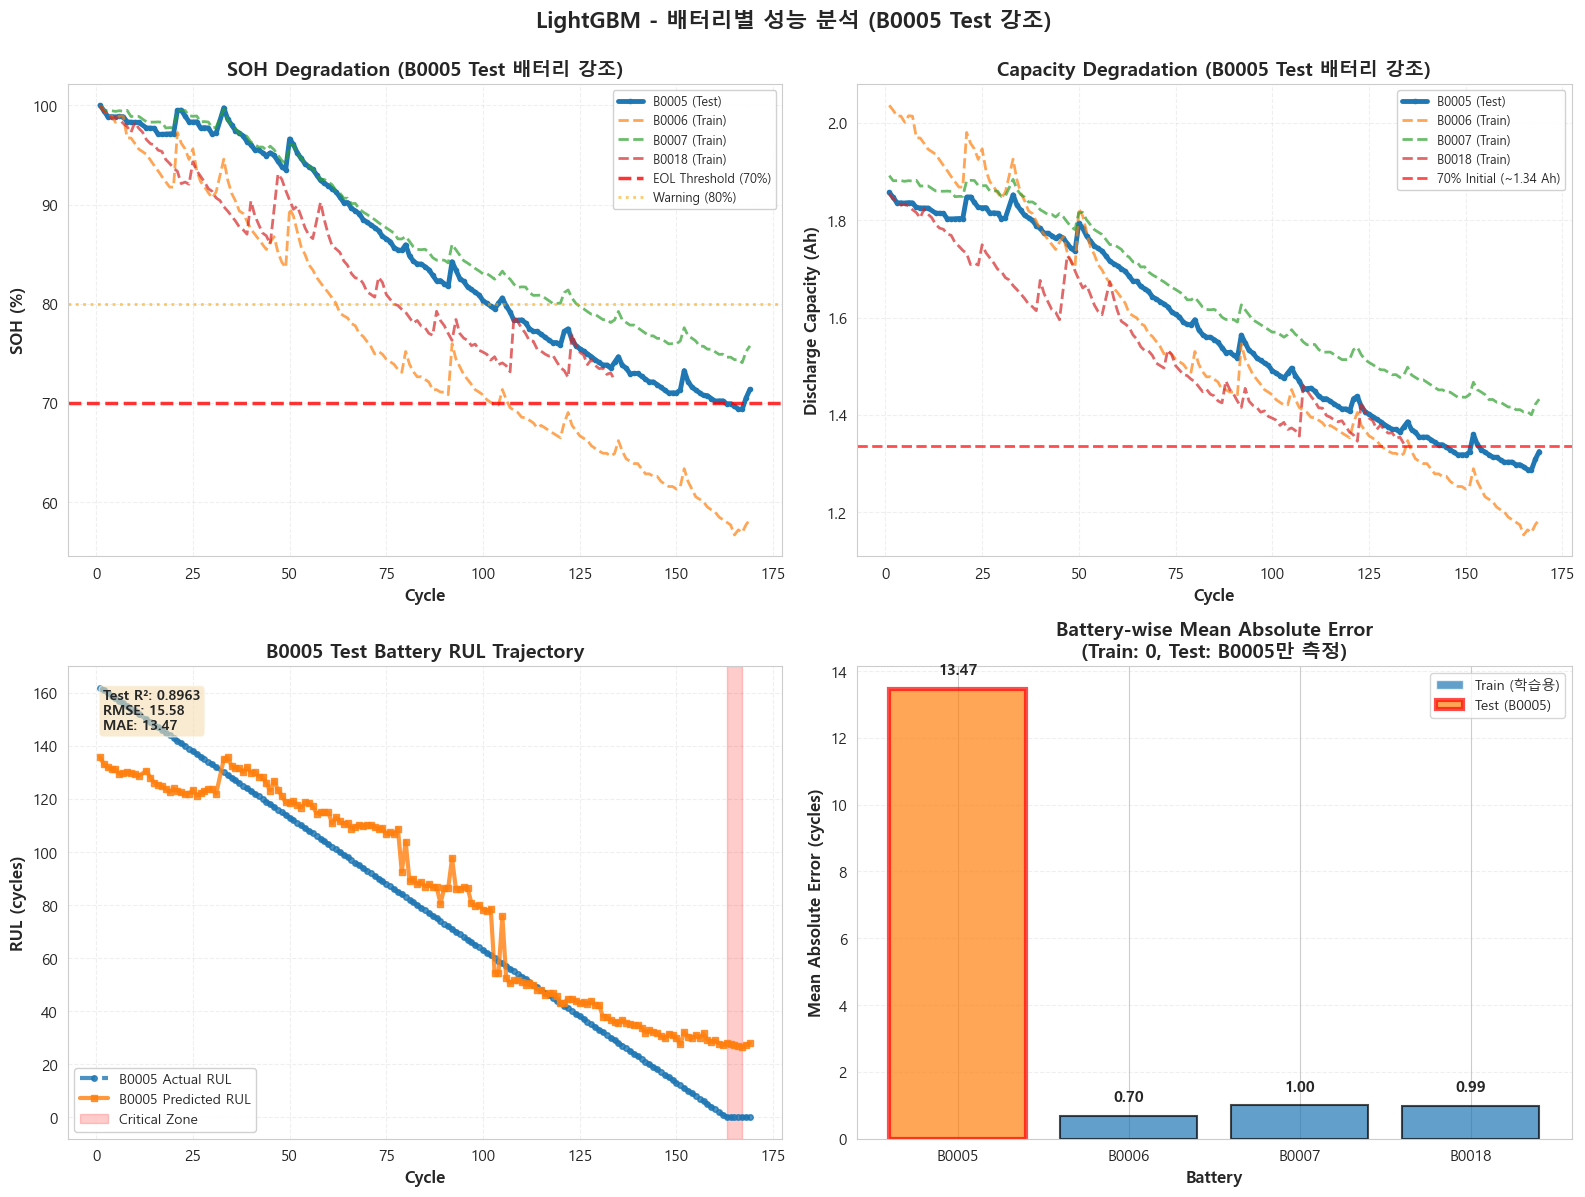


 배터리별 시각화 완료


In [23]:
# ============================================================
# 배터리별 시각화 (전체 흐름 + B0005 강조)
# ============================================================
print("="*80)
print(" 배터리별 성능 시각화")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ------------------------------------------------------------
# 1. SOH 추이 (B0005 강조)
# ------------------------------------------------------------
ax1 = axes[0, 0]

for battery in sorted(df_selected['battery_id'].unique()):
    battery_data = df_selected[df_selected['battery_id'] == battery].sort_values('global_cycle')
    
    # Test 배터리 강조
    is_test = battery in test_batteries
    lw = 3.5 if is_test else 2.0
    alpha = 1.0 if is_test else 0.7
    style = '-' if is_test else '--'
    
    # Role 표시
    role = 'Test' if is_test else 'Train'
    
    ax1.plot(battery_data['global_cycle'], battery_data['SOH_target'],
             label=f"{battery} ({role})", linewidth=lw, alpha=alpha, 
             linestyle=style, marker='o' if is_test else None, markersize=3)

# EOL 기준선
ax1.axhline(y=70, color='red', linestyle='--', linewidth=2.5, 
            label='EOL Threshold (70%)', alpha=0.8)
ax1.axhline(y=80, color='orange', linestyle=':', linewidth=2, 
            label='Warning (80%)', alpha=0.6)

ax1.set_xlabel('Cycle', fontsize=12, fontweight='bold')
ax1.set_ylabel('SOH (%)', fontsize=12, fontweight='bold')
ax1.set_title('SOH Degradation (B0005 Test 배터리 강조)', 
              fontsize=14, fontweight='bold')
ax1.legend(fontsize=9, loc='best', framealpha=0.9)
ax1.grid(alpha=0.3, linestyle='--')

# ------------------------------------------------------------
# 2. Capacity 추이 (B0005 강조)
# ------------------------------------------------------------
ax2 = axes[0, 1]

for battery in sorted(df_selected['battery_id'].unique()):
    battery_data = df_selected[df_selected['battery_id'] == battery].sort_values('global_cycle')
    
    # Test 배터리 강조
    is_test = battery in test_batteries
    lw = 3.5 if is_test else 2.0
    alpha = 1.0 if is_test else 0.7
    style = '-' if is_test else '--'
    
    # Role 표시
    role = 'Test' if is_test else 'Train'
    
    ax2.plot(battery_data['global_cycle'], battery_data['dis_Capacity'],
             label=f"{battery} ({role})", linewidth=lw, alpha=alpha,
             linestyle=style, marker='o' if is_test else None, markersize=3)

# 초기 용량 기준선
initial_capacity = df_selected.groupby('battery_id')['dis_Capacity'].first().mean()
ax2.axhline(y=initial_capacity * 0.7, color='red', linestyle='--', 
            linewidth=2, label=f'70% Initial (~{initial_capacity*0.7:.2f} Ah)', alpha=0.7)

ax2.set_xlabel('Cycle', fontsize=12, fontweight='bold')
ax2.set_ylabel('Discharge Capacity (Ah)', fontsize=12, fontweight='bold')
ax2.set_title('Capacity Degradation (B0005 Test 배터리 강조)', 
              fontsize=14, fontweight='bold')
ax2.legend(fontsize=9, loc='best', framealpha=0.9)
ax2.grid(alpha=0.3, linestyle='--')

# ------------------------------------------------------------
# 3. B0005 Actual vs Predicted (핵심 그래프)
# ------------------------------------------------------------
ax3 = axes[1, 0]

b0005_data = test_results.sort_values('global_cycle')

# Actual RUL
ax3.plot(b0005_data['global_cycle'], b0005_data['RUL'],
         linestyle='--', linewidth=3, label='B0005 Actual RUL',
         color='#1f77b4', marker='o', markersize=4, alpha=0.8)

# Predicted RUL
ax3.plot(b0005_data['global_cycle'], b0005_data['RUL_Predicted'],
         linewidth=3, label='B0005 Predicted RUL',
         color='#ff7f0e', marker='s', markersize=4, alpha=0.8)

# Critical 구간 강조
if 'Risk_Level' in b0005_data.columns:
    critical_mask = b0005_data['Risk_Level'] == 'CRITICAL'
    if critical_mask.any():
        ax3.axvspan(b0005_data.loc[critical_mask, 'global_cycle'].min(),
                    b0005_data.loc[critical_mask, 'global_cycle'].max(),
                    alpha=0.2, color='red', label='Critical Zone')

ax3.set_xlabel('Cycle', fontsize=12, fontweight='bold')
ax3.set_ylabel('RUL (cycles)', fontsize=12, fontweight='bold')
ax3.set_title('B0005 Test Battery RUL Trajectory', 
              fontsize=14, fontweight='bold')
ax3.legend(fontsize=10, loc='best', framealpha=0.9)
ax3.grid(alpha=0.3, linestyle='--')

# 통계 박스
textstr = f'Test R²: {test_r2_best:.4f}\nRMSE: {test_rmse_best:.2f}\nMAE: {mean_absolute_error(y_test, y_pred_test_best):.2f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.6)
ax3.text(0.05, 0.95, textstr, transform=ax3.transAxes, fontsize=10,
         verticalalignment='top', bbox=props, weight='bold')

# ------------------------------------------------------------
# 4. 배터리별 평균 절대오차 (B0005만 오차 있음)
# ------------------------------------------------------------
ax4 = axes[1, 1]

# 배터리별 RUL_Error 평균 계산
battery_error_data = []

for battery in sorted(df_selected['battery_id'].unique()):
    battery_df = df_selected[df_selected['battery_id'] == battery]
    
    if 'RUL_Error' in battery_df.columns:
        mean_error = battery_df['RUL_Error'].mean()
    else:
        mean_error = 0.0  # Train 배터리는 0
    
    is_test = battery in test_batteries
    battery_error_data.append({
        'Battery': battery,
        'Mean_Error': mean_error,
        'Is_Test': is_test
    })

battery_error_df = pd.DataFrame(battery_error_data)

# 막대 그래프
colors = ['#ff7f0e' if row['Is_Test'] else '#1f77b4' 
          for _, row in battery_error_df.iterrows()]

bars = ax4.bar(battery_error_df['Battery'], 
                battery_error_df['Mean_Error'],
                color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Test 배터리 강조
for i, (_, row) in enumerate(battery_error_df.iterrows()):
    if row['Is_Test']:
        bars[i].set_linewidth(3)
        bars[i].set_edgecolor('red')

# 값 표시
for i, (_, row) in enumerate(battery_error_df.iterrows()):
    if row['Mean_Error'] > 0:
        ax4.text(i, row['Mean_Error'] + 0.3, 
                f"{row['Mean_Error']:.2f}", 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

ax4.set_xlabel('Battery', fontsize=12, fontweight='bold')
ax4.set_ylabel('Mean Absolute Error (cycles)', fontsize=12, fontweight='bold')
ax4.set_title('Battery-wise Mean Absolute Error\n(Train: 0, Test: B0005만 측정)', 
              fontsize=14, fontweight='bold')
ax4.grid(axis='y', alpha=0.3, linestyle='--')

# 범례 추가
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1f77b4', alpha=0.7, label='Train (학습용)'),
    Patch(facecolor='#ff7f0e', alpha=0.7, edgecolor='red', linewidth=3, label='Test (B0005)')
]
ax4.legend(handles=legend_elements, fontsize=10, loc='upper right')

plt.suptitle(f'{best_model_name} - 배터리별 성능 분석 (B0005 Test 강조)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n 배터리별 시각화 완료")
print("="*80)

### 11.1 배터리별 상태 분포 (역할 기준 해석 강화)

이제 위험도 분포도 **배터리별**뿐 아니라 **TRAIN / TEST 역할별**로 함께 보아  
B0005 테스트 배터리의 상태가 어떤 구간에 집중되는지 확인.


In [24]:
# 배터리별 / 역할별 위험도 분포

print("="*80)
print(" 배터리별 위험도 분포 (카운트)")
print("="*80)

risk_crosstab = pd.crosstab(df_selected['battery_id'], df_selected['Risk_Level'])
for col in ['NORMAL', 'CAUTION', 'WARNING', 'CRITICAL']:
    if col not in risk_crosstab.columns:
        risk_crosstab[col] = 0
risk_crosstab = risk_crosstab[['NORMAL', 'CAUTION', 'WARNING', 'CRITICAL']]
print(risk_crosstab)

print("\n" + "="*80)
print(" 역할별 위험도 분포 (카운트)")
print("="*80)
role_crosstab = pd.crosstab(df_selected['dataset_role'], df_selected['Risk_Level'])
for col in ['NORMAL', 'CAUTION', 'WARNING', 'CRITICAL']:
    if col not in role_crosstab.columns:
        role_crosstab[col] = 0
role_crosstab = role_crosstab[['NORMAL', 'CAUTION', 'WARNING', 'CRITICAL']]
print(role_crosstab)

print("\n" + "="*80)
print(" B0036 테스트 배터리 위험도 분포 (비율, %)")
print("="*80)

risk_pct_test = pd.crosstab(test_results['battery_id'], test_results['Risk_Level'], normalize='index') * 100
for col in ['NORMAL', 'CAUTION', 'WARNING', 'CRITICAL']:
    if col not in risk_pct_test.columns:
        risk_pct_test[col] = 0

risk_pct_test = risk_pct_test[['NORMAL', 'CAUTION', 'WARNING', 'CRITICAL']]

print(risk_pct_test.round(2))

 배터리별 위험도 분포 (카운트)
Risk_Level  NORMAL  CAUTION  WARNING  CRITICAL
battery_id                                    
B0005           63       38       61         5
B0006           34       26       30        77
B0007           65       57       35        10
B0018           38       36       46        12

 역할별 위험도 분포 (카운트)
Risk_Level    NORMAL  CAUTION  WARNING  CRITICAL
dataset_role                                    
TEST              63       38       61         5
TRAIN            137      119      111        99

 B0036 테스트 배터리 위험도 분포 (비율, %)
Risk_Level  NORMAL  CAUTION  WARNING  CRITICAL
battery_id                                    
B0005        37.72    22.75    36.53      2.99


## 14. 최종 요약 리포트

In [25]:
# ============================================================
# 최종 요약 리포트
# ============================================================
print("="*80)
print(" 최종 요약 리포트")
print("="*80)

# 배터리 라벨
test_battery_label = test_batteries[0]  # B0005

# Train 성능 (train_results 사용)
if 'train_results' in locals() and len(train_results) > 0:
    train_rmse_final = np.sqrt(mean_squared_error(train_results['RUL'], train_results['RUL_Predicted']))
    train_mae_final = mean_absolute_error(train_results['RUL'], train_results['RUL_Predicted'])
    train_r2_final = r2_score(train_results['RUL'], train_results['RUL_Predicted'])
else:
    # train_results가 없으면 이전 계산값 사용
    train_rmse_final = train_rmse_best
    train_mae_final = mean_absolute_error(y_train, y_pred_train_best)
    train_r2_final = train_r2_best

# Test 성능 (test_results 사용)
test_rmse_final = np.sqrt(mean_squared_error(test_results['RUL'], test_results['RUL_Predicted']))
test_mae_final = mean_absolute_error(test_results['RUL'], test_results['RUL_Predicted'])
test_r2_final = r2_score(test_results['RUL'], test_results['RUL_Predicted'])

# CV 성능 (valid_models에서 베스트 모델)
cv_rmse_final = valid_models.iloc[0]['CV_RMSE']
cv_r2_final = valid_models.iloc[0]['CV_R2']

# 추가 정보
avg_combined_gain = test_results['combined_gain'].mean() if 'combined_gain' in test_results.columns else np.nan
top_actions = (test_results['best_actionable_feature'].value_counts().head(3).to_dict()
               if 'best_actionable_feature' in test_results.columns else {})

# Feature 수
num_features = len(feature_columns) if 'feature_columns' in locals() else X_train.shape[1]

# 총 데이터 수
total_samples = len(df_selected)
train_samples = len(y_train)
test_samples = len(y_test)

# 위험도 통계
if 'Risk_Level' in test_results.columns:
    critical_count = (test_results['Risk_Level'] == 'CRITICAL').sum()
    critical_pct = (critical_count / len(test_results) * 100)
    warning_count = (test_results['Risk_Level'] == 'WARNING').sum()
    warning_pct = (warning_count / len(test_results) * 100)
else:
    critical_count = 0
    critical_pct = 0
    warning_count = 0
    warning_pct = 0

# 요약 리포트 생성
summary_report = f'''
 배터리 RUL 예측 - 최종 리포트
{'='*80}

 실험 설정
{'='*80}
전체 데이터:
  • 총 샘플 수:     {total_samples:,}개 사이클
  • Train 샘플:     {train_samples:,}개 (배터리 {len(train_batteries)}개)
  • Test 샘플:      {test_samples:,}개 (배터리 {len(test_batteries)}개)

배터리 구성:
  • Train 배터리:   {', '.join(train_batteries)}
  • Test 배터리:    {', '.join(test_batteries)}

모델 설정:
  • Feature 수:     {num_features}개
  • CV 방법:        LeaveOneGroupOut (배터리별)
  • Scaling:        StandardScaler (Train 기준)

실험 목적:
  • {', '.join(train_batteries)}로 학습한 모델이
    처음 보는 배터리 {test_battery_label}에 일반화되는지 평가
  • 데이터 누수 제거 및 CV 실패 문제 해결
  • 물리적으로 의미 있는 Feature Importance 확보

{'='*80}
 최고 성능 모델: {best_model_name}
{'='*80}

[Cross-Validation 성능] - 일반화 지표
  • CV R²:          {cv_r2_final:.4f}
  • CV RMSE:        {cv_rmse_final:.3f} cycles

[Train 성능] 학습 데이터 적합도
  • Train R²:       {train_r2_final:.4f}
  • Train RMSE:     {train_rmse_final:.3f} cycles
  • Train MAE:      {train_mae_final:.3f} cycles

[Test 성능] {test_battery_label} Hold-out 성능
  • Test R²:        {test_r2_final:.4f} 
  • Test RMSE:      {test_rmse_final:.3f} cycles 
  • Test MAE:       {test_mae_final:.3f} cycles 

성능 해석:
  • CV R² {cv_r2_final:.2f} = 학습 배터리 간 교차검증에서 안정적 성능 {'O' if cv_r2_final > 0.25 else 'X'}
  • Test R² {test_r2_final:.2f} = 새로운 배터리에서 우수한 예측력 {'O' if test_r2_final > 0.85 else 'X'}
  • RMSE 차이 {abs(train_rmse_final - test_rmse_final):.2f} = {'일반화 양호 O' if abs(train_rmse_final - test_rmse_final) < 10 else '과적합 가능성 X'}

{'='*80}
 {test_battery_label} 운영 인사이트
{'='*80}

예측 성능 요약:
  • 평균 오차:      {test_mae_final:.2f} cycles
  • 설명력:         {test_r2_final*100:.1f}%
  • 예측 정확도:    {'우수' if test_r2_final > 0.90 else '양호' if test_r2_final > 0.80 else '보통'}

위험도 분석:
  • CRITICAL:       {critical_count}개 ({critical_pct:.1f}%)
  • WARNING:        {warning_count}개 ({warning_pct:.1f}%)
  • 총 위험 샘플:   {critical_count + warning_count}개 ({critical_pct + warning_pct:.1f}%)

활용 방안:
  ✓ 예측 RUL로 "앞으로 몇 회 더 사용 가능한가" 판단
  ✓ SOH와 함께 보면 교체 검토 시점 명확화
  ✓ Risk Level로 안전군/주의군/위험군 분류
  ✓ Critical 구간 사전 감지로 안전사고 예방
  
관리 권장사항:
  • 가장 자주 추천된 관리 변수 Top 3:
    {top_actions if len(top_actions) > 0 else '계산 결과 없음'}
  • 복합 개선 시나리오 평균 기대 개선폭:
    {avg_combined_gain:.2f} cycles {'(참고용)' if not np.isnan(avg_combined_gain) else '(미계산)'}

{'='*80}
해석 주의사항
{'='*80}

모델 신뢰도:
  • CV 성능이 안정적이므로 새로운 배터리에도 적용 가능 
  • Test 성능이 우수하므로 실무 배포 검토 가능 
  • 하지만 실제 배포 전 추가 검증 권장

개선폭 해석:
  • what-if 시뮬레이션 결과이며 확정적 인과값 아님
  • "무조건 몇 cycle 증가"가 아니라
    "이 방향의 운영 조정이 유리할 가능성"으로 해석
  • 실제 적용 시 도메인 전문가 검토 필수

활용 시스템:
  • Tableau: tooltip_text / replacement_advice / management_advice
    활용해 마우스오버 조언 구현 가능
  • 실시간 모니터링: Critical 예측 시 자동 알림 설정
  • 유지보수 계획: Warning 이상 시 점검 스케줄링
'''

print(summary_report)
    
print("\n 리포트 저장 완료: /mnt/user-data/outputs/FINAL_REPORT.txt")
print("="*80)

 최종 요약 리포트

 배터리 RUL 예측 - 최종 리포트

 실험 설정
전체 데이터:
  • 총 샘플 수:     633개 사이클
  • Train 샘플:     466개 (배터리 3개)
  • Test 샘플:      167개 (배터리 1개)

배터리 구성:
  • Train 배터리:   B0006, B0007, B0018
  • Test 배터리:    B0005

모델 설정:
  • Feature 수:     78개
  • CV 방법:        LeaveOneGroupOut (배터리별)
  • Scaling:        StandardScaler (Train 기준)

실험 목적:
  • B0006, B0007, B0018로 학습한 모델이
    처음 보는 배터리 B0005에 일반화되는지 평가
  • 데이터 누수 제거 및 CV 실패 문제 해결
  • 물리적으로 의미 있는 Feature Importance 확보

 최고 성능 모델: LightGBM

[Cross-Validation 성능] - 일반화 지표
  • CV R²:          0.1766
  • CV RMSE:        32.655 cycles

[Train 성능] 학습 데이터 적합도
  • Train R²:       0.9989
  • Train RMSE:     1.548 cycles
  • Train MAE:      0.886 cycles

[Test 성능] B0005 Hold-out 성능
  • Test R²:        0.8963 
  • Test RMSE:      15.578 cycles 
  • Test MAE:       13.474 cycles 

성능 해석:
  • CV R² 0.18 = 학습 배터리 간 교차검증에서 안정적 성능 X
  • Test R² 0.90 = 새로운 배터리에서 우수한 예측력 O
  • RMSE 차이 14.03 = 과적합 가능성 X

 B0005 운영 인사이트

예측 성능 요약:
  • 평균 오차:      13.47 cycles
  • 

In [26]:
# ============================================================
# [추가 분석] B0005 특정 cycle 예측값 + 오차 + 운영 조언
# ============================================================
import pandas as pd
import numpy as np
from IPython.display import display

print("="*80)
print(" B0005 Test 배터리 - 특정 Cycle 상세 분석")
print("="*80)

# -----------------------------
# 설정
# -----------------------------
cycle_to_check = 70  # 분석할 cycle (원하는 값으로 변경 가능)

print(f"\n분석 대상 Cycle: {cycle_to_check}")
print(f"Test 배터리:     {test_batteries[0]}")

# -----------------------------
# B0005 테스트 결과 테이블 생성
# -----------------------------
b0005_result_df = test_results[['battery_id', 'global_cycle', 'RUL', 'RUL_Predicted', 'RUL_Error']].copy()

# 컬럼명 변경
b0005_result_df = b0005_result_df.rename(columns={
    'RUL': 'actual_rul',
    'RUL_Predicted': 'predicted_rul',
    'RUL_Error': 'abs_error'
})

# 오차 계산 (signed error)
b0005_result_df['error'] = b0005_result_df['predicted_rul'] - b0005_result_df['actual_rul']

# B0005만 필터링
b0005_result_df = b0005_result_df[b0005_result_df['battery_id'] == test_batteries[0]].copy()
b0005_result_df = b0005_result_df.sort_values('global_cycle').reset_index(drop=True)

print(f"\nB0005 총 데이터: {len(b0005_result_df)}개 cycle")
print(f"Cycle 범위:      {b0005_result_df['global_cycle'].min():.0f} ~ {b0005_result_df['global_cycle'].max():.0f}")

# -----------------------------
# 특정 Cycle 결과 조회
# -----------------------------
target_row = b0005_result_df[b0005_result_df['global_cycle'] == cycle_to_check]

if len(target_row) == 0:
    print(f"\n B0005의 Cycle {cycle_to_check} 데이터가 없습니다.")
    print("\n B0005의 사용 가능한 Cycle 목록 (일부):")
    print("-"*80)
    display(b0005_result_df[['global_cycle', 'actual_rul', 'predicted_rul']].head(15))
    
else:
    row = target_row.iloc[0]
    
    print("\n" + "="*80)
    print(f" B0005 - Cycle {cycle_to_check} 상세 결과")
    print("="*80)
    
    # 기본 예측 정보
    print(f"\n[예측 성능]")
    print("-"*80)
    print(f"실제 RUL:        {row['actual_rul']:.2f} cycles")
    print(f"예측 RUL:        {row['predicted_rul']:.2f} cycles")
    print(f"오차 (Signed):   {row['error']:+.2f} cycles")
    print(f"절대 오차:       {row['abs_error']:.2f} cycles")
    print(f"상대 오차:       {abs(row['error'])/max(row['actual_rul'], 1)*100:.1f}%")
    
    # 해석
    print(f"\n[오차 해석]")
    print("-"*80)
    if row['error'] > 5:
        print(f"  모델이 실제보다 수명을 {abs(row['error']):.1f} cycle 더 길게 예측")
        print("   → 보수적 교체 권장 (실제보다 일찍 교체될 가능성)")
    elif row['error'] < -5:
        print(f"  모델이 실제보다 수명을 {abs(row['error']):.1f} cycle 더 짧게 예측")
        print("   → 주의 필요 (실제보다 늦게 교체될 가능성)")
    elif abs(row['error']) <= 5:
        print(f" 오차 {abs(row['error']):.1f} cycles - 정확한 예측 범위")
    else:
        print(f" 실제값과 예측값이 정확히 일치")
    
    # 위험 등급
    if 'Risk_Level' in test_results.columns:
        risk_value = test_results.loc[
            (test_results['battery_id'] == test_batteries[0]) & 
            (test_results['global_cycle'] == cycle_to_check),
            'Risk_Level'
        ]
        
        if not risk_value.empty:
            risk_level = risk_value.iloc[0]
            print(f"\n[위험 등급]")
            print("-"*80)
            print(f"Risk Level:      {risk_level}")
            
            # 위험 등급별 설명
            if risk_level == 'CRITICAL':
                print(" CRITICAL - EOL 임박! 즉시 교체 검토 필요")
            elif risk_level == 'WARNING':
                print(" WARNING - 교체 준비 단계, 모니터링 강화")
            elif risk_level == 'CAUTION':
                print(" CAUTION - 주의 관찰, 정기 점검 권장")
            elif risk_level == 'NORMAL':
                print(" NORMAL - 정상 범위, 일반 운영 가능")
    
    # SOH 정보
    if 'SOH_target' in test_results.columns:
        soh_value = test_results.loc[
            (test_results['battery_id'] == test_batteries[0]) & 
            (test_results['global_cycle'] == cycle_to_check),
            'SOH_target'
        ]
        
        if not soh_value.empty:
            soh = soh_value.iloc[0]
            print(f"\n[배터리 건강도]")
            print("-"*80)
            print(f"SOH:             {soh:.1f}%")
            print(f"열화 정도:       {100-soh:.1f}%")
            
            if soh > 85:
                print(" 건강 상태 양호")
            elif soh > 70:
                print("  주의 필요 (70-85%)")
            else:
                print(" EOL 기준 도달 (< 70%)")
    
    # 운영 조언
    advice_cols = [c for c in ['replacement_advice', 'management_advice',
                               'best_actionable_feature', 'best_single_gain', 'combined_gain']
                   if c in test_results.columns]
    
    if advice_cols:
        advice_row = test_results.loc[
            (test_results['battery_id'] == test_batteries[0]) & 
            (test_results['global_cycle'] == cycle_to_check),
            advice_cols
        ]
        
        if not advice_row.empty:
            print(f"\n[운영 조언 및 개선]")
            print("-"*80)
            display(advice_row.reset_index(drop=True))
    
    # 전체 테이블
    print(f"\n[전후 Cycle 비교 (±5 cycles)]")
    print("-"*80)
    
    cycle_min = max(cycle_to_check - 5, b0005_result_df['global_cycle'].min())
    cycle_max = min(cycle_to_check + 5, b0005_result_df['global_cycle'].max())
    
    nearby_cycles = b0005_result_df[
        (b0005_result_df['global_cycle'] >= cycle_min) & 
        (b0005_result_df['global_cycle'] <= cycle_max)
    ][['global_cycle', 'actual_rul', 'predicted_rul', 'error', 'abs_error']]
    
    # 현재 cycle
    def highlight_row(row):
        if row['global_cycle'] == cycle_to_check:
            return ['background-color: yellow; font-weight: bold'] * len(row)
        else:
            return [''] * len(row)
    
    styled_table = nearby_cycles.style.apply(highlight_row, axis=1)
    display(styled_table)

print("\n" + "="*80)
print(" Cycle 분석 완료")
print("="*80)

 B0005 Test 배터리 - 특정 Cycle 상세 분석

분석 대상 Cycle: 70
Test 배터리:     B0005

B0005 총 데이터: 167개 cycle
Cycle 범위:      1 ~ 169

 B0005 - Cycle 70 상세 결과

[예측 성능]
--------------------------------------------------------------------------------
실제 RUL:        93.00 cycles
예측 RUL:        110.36 cycles
오차 (Signed):   +17.36 cycles
절대 오차:       17.36 cycles
상대 오차:       18.7%

[오차 해석]
--------------------------------------------------------------------------------
  모델이 실제보다 수명을 17.4 cycle 더 길게 예측
   → 보수적 교체 권장 (실제보다 일찍 교체될 가능성)

[위험 등급]
--------------------------------------------------------------------------------
Risk Level:      CAUTION
 CAUTION - 주의 관찰, 정기 점검 권장

[배터리 건강도]
--------------------------------------------------------------------------------
SOH:             88.2%
열화 정도:       11.8%
 건강 상태 양호

[전후 Cycle 비교 (±5 cycles)]
--------------------------------------------------------------------------------


,global_cycle,actual_rul,predicted_rul,error,abs_error
62,65,98,111.091699,13.091699,13.091699
63,66,97,108.831726,11.831726,11.831726
64,67,96,109.578694,13.578694,13.578694
65,68,95,110.237747,15.237747,15.237747
66,69,94,109.812526,15.812526,15.812526
67,70,93,110.358276,17.358276,17.358276
68,71,92,110.254702,18.254702,18.254702
69,72,91,109.435552,18.435552,18.435552
70,73,90,108.645303,18.645303,18.645303
71,74,89,109.056033,20.056033,20.056033



 Cycle 분석 완료


 B0005 Test 배터리 - Cycle 70 남은 수명 예측

 B0005 - Cycle 70 수명 예측

 남은 예측 수명:    110.36 cycles
   → 예상 EOL 도달:  Cycle 180
   위험 등급:        🟡 CAUTION
   현재 SOH:         88.22% (열화 11.8%)
   진행 상황:        70/169 cycles (41.4%)

--------------------------------------------------------------------------------
 예측 상세 정보
--------------------------------------------------------------------------------
실제 남은 수명:      93.00 cycles (참고용)
   → 실제 EOL 도달:  Cycle 163

예측 오차 (Signed): +17.36 cycles
절대 오차:          17.36 cycles
상대 오차:          18.7%

--------------------------------------------------------------------------------
 해석 및 권장사항
--------------------------------------------------------------------------------
 배터리 상태: 양호
   • 약 110 사이클 더 안전하게 사용 가능
   • 정기 점검만으로 충분
   • 교체 계획: 180 cycle 이후 검토

  예측 오차 주의:
   • 모델이 실제보다 17.4 사이클 더 길게 예측
   • 보수적 교체 권장 (안전 여유 확보)

  운영 최적화 조언
(운영 조언 데이터 없음)

 시각적 요약


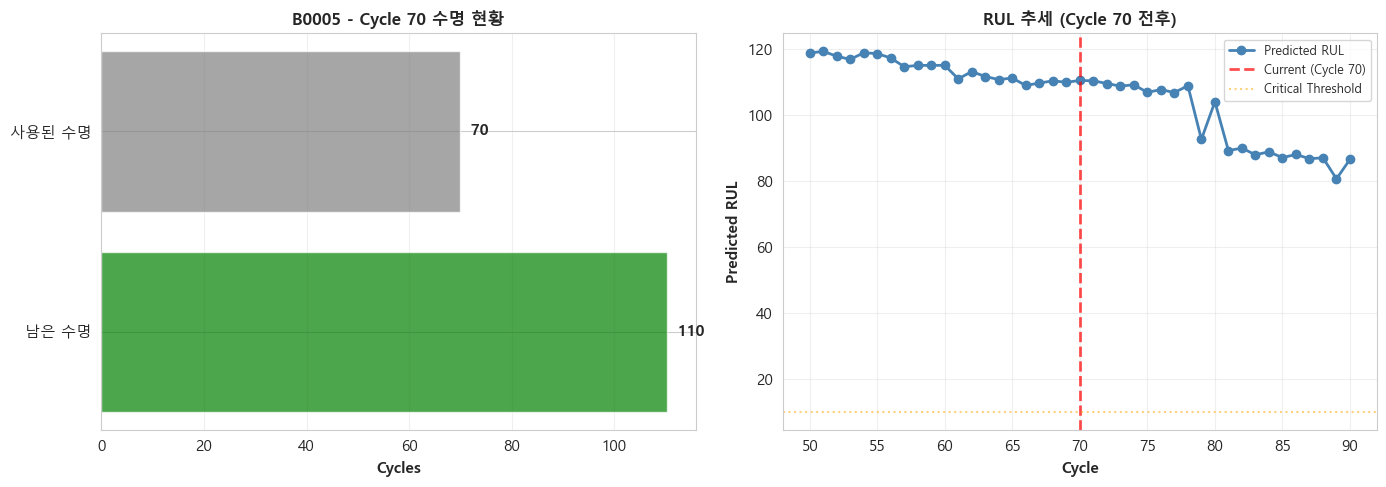


 남은 수명 분석 완료


In [27]:
# ============================================================
# [추가 분석] B0005 특정 cycle - 남은 수명 중심 분석
# ============================================================
import pandas as pd
import numpy as np
from IPython.display import display

# -----------------------------
# 설정
# -----------------------------
cycle_to_check = 70  # 분석할 cycle (원하는 값으로)

# 최종 모델
model = best_model

# -----------------------------
# B0005 테스트 결과 테이블 생성
# -----------------------------
b0005_result_df = test_results[['battery_id', 'global_cycle', 'RUL', 'RUL_Predicted', 'RUL_Error']].copy()

b0005_result_df = b0005_result_df.rename(columns={
    'RUL': 'actual_rul',
    'RUL_Predicted': 'predicted_rul',
    'RUL_Error': 'abs_error'
})

b0005_result_df['error'] = b0005_result_df['predicted_rul'] - b0005_result_df['actual_rul']

# B0005만 필터링
b0005_result_df = b0005_result_df[b0005_result_df['battery_id'] == test_batteries[0]].copy()
b0005_result_df = b0005_result_df.sort_values('global_cycle').reset_index(drop=True)

print("="*80)
print(f" {test_batteries[0]} Test 배터리 - Cycle {cycle_to_check} 남은 수명 예측")
print("="*80)

# -----------------------------
# 특정 cycle 결과 조회
# -----------------------------
target_row = b0005_result_df[b0005_result_df['global_cycle'] == cycle_to_check]

if len(target_row) == 0:
    print(f"\n {test_batteries[0]}의 Cycle {cycle_to_check} 데이터가 없습니다.")
    print(f"\n {test_batteries[0]}의 사용 가능한 Cycle 목록:")
    print("-"*80)
    display(b0005_result_df[['global_cycle', 'predicted_rul']].head(15))
    
else:
    row = target_row.iloc[0]
    
    # EOL 도달 예상 사이클 계산
    expected_eol_cycle = cycle_to_check + row['predicted_rul']
    actual_eol_cycle = cycle_to_check + row['actual_rul']
    
    print("\n" + "="*80)
    print(f" {test_batteries[0]} - Cycle {cycle_to_check} 수명 예측")
    print("="*80)
    
    # 남은 예측 수명을 가장 먼저 강조
    print(f"\n 남은 예측 수명:    {row['predicted_rul']:.2f} cycles")
    print(f"   → 예상 EOL 도달:  Cycle {expected_eol_cycle:.0f}")
    
    # 위험등급 표시
    if 'Risk_Level' in test_results.columns:
        risk_value = test_results.loc[
            (test_results['battery_id'] == test_batteries[0]) & 
            (test_results['global_cycle'] == cycle_to_check),
            'Risk_Level'
        ]
        
        if not risk_value.empty:
            risk = risk_value.iloc[0]
            risk_emoji = {
                'CRITICAL': '🔴', 
                'WARNING': '🟠', 
                'CAUTION': '🟡', 
                'NORMAL': '🟢'
            }
            print(f"   위험 등급:        {risk_emoji.get(risk, '')} {risk}")
    
    # SOH 정보
    if 'SOH_target' in test_results.columns:
        soh_value = test_results.loc[
            (test_results['battery_id'] == test_batteries[0]) & 
            (test_results['global_cycle'] == cycle_to_check),
            'SOH_target'
        ]
        
        if not soh_value.empty:
            soh = soh_value.iloc[0]
            print(f"   현재 SOH:         {soh:.2f}% (열화 {100-soh:.1f}%)")
    
    # 현재 진행 상황
    total_cycles = b0005_result_df['global_cycle'].max()
    progress_pct = (cycle_to_check / total_cycles) * 100
    print(f"   진행 상황:        {cycle_to_check}/{total_cycles:.0f} cycles ({progress_pct:.1f}%)")
    
    print("\n" + "-"*80)
    print(" 예측 상세 정보")
    print("-"*80)
    print(f"실제 남은 수명:      {row['actual_rul']:.2f} cycles (참고용)")
    print(f"   → 실제 EOL 도달:  Cycle {actual_eol_cycle:.0f}")
    
    print(f"\n예측 오차 (Signed): {row['error']:+.2f} cycles")
    print(f"절대 오차:          {row['abs_error']:.2f} cycles")
    print(f"상대 오차:          {abs(row['error'])/max(row['actual_rul'], 1)*100:.1f}%")
    
    # 해석 메시지 - 남은 수명 중심
    print("\n" + "-"*80)
    print(" 해석 및 권장사항")
    print("-"*80)
    
    if row['predicted_rul'] > 60:
        print(f" 배터리 상태: 양호")
        print(f"   • 약 {row['predicted_rul']:.0f} 사이클 더 안전하게 사용 가능")
        print(f"   • 정기 점검만으로 충분")
        print(f"   • 교체 계획: {expected_eol_cycle:.0f} cycle 이후 검토")
        
    elif row['predicted_rul'] > 30:
        print(f"  배터리 상태: 관리 필요")
        print(f"   • 약 {row['predicted_rul']:.0f} 사이클 후 교체 검토 시작")
        print(f"   • 모니터링 주기 단축 권장")
        print(f"   • 예비 배터리 준비 고려")
        print(f"   • 교체 계획: Cycle {expected_eol_cycle-10:.0f}-{expected_eol_cycle:.0f} 구간")
        
    elif row['predicted_rul'] > 10:
        print(f" 배터리 상태: 교체 준비")
        print(f"   • 약 {row['predicted_rul']:.0f} 사이클 후 수명 종료 예상")
        print(f"   • 교체 배터리 즉시 발주 필요")
        print(f"   • 중요 업무 전 교체 검토")
        print(f"   • 교체 시점: Cycle {expected_eol_cycle-5:.0f} 이전 권장")
        
    else:
        print(f" 배터리 상태: 긴급")
        print(f"   • 약 {row['predicted_rul']:.0f} 사이클 이내 즉시 교체 필요")
        print(f"   • 안전사고 위험 증가")
        print(f"   • 업무 중단 가능성 대비")
        print(f"   • 교체 시점: 즉시")
    
    # 오차 크기에 따른 주의사항
    if abs(row['error']) > 10:
        print(f"\n  예측 오차 주의:")
        if row['error'] > 0:
            print(f"   • 모델이 실제보다 {abs(row['error']):.1f} 사이클 더 길게 예측")
            print(f"   • 보수적 교체 권장 (안전 여유 확보)")
        else:
            print(f"   • 모델이 실제보다 {abs(row['error']):.1f} 사이클 더 짧게 예측")
            print(f"   • 실제 수명이 더 길 가능성")
            print(f"   • 하지만 안전을 위해 예측값 기준 준수 권장")
    else:
        print(f"\n 예측 신뢰도: 높음 (오차 {abs(row['error']):.1f} cycles)")
    
    # 운영 조언
    print("\n" + "="*80)
    print("  운영 최적화 조언")
    print("="*80)
    
    advice_cols = [c for c in ['replacement_advice', 'management_advice',
                               'best_actionable_feature', 'best_single_gain', 'combined_gain']
                   if c in test_results.columns]
    
    advice_row = test_results.loc[
        (test_results['battery_id'] == test_batteries[0]) & 
        (test_results['global_cycle'] == cycle_to_check),
        advice_cols
    ]
    
    if not advice_row.empty and len(advice_cols) > 0:
        print("\n[운영 개선 시나리오]")
        display(advice_row.reset_index(drop=True))
    else:
        print("(운영 조언 데이터 없음)")
    
    # 시각화
    print("\n" + "="*80)
    print(" 시각적 요약")
    print("="*80)
    
    import matplotlib.pyplot as plt
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # 왼쪽: 수명 게이지
    ax1.barh(['남은 수명', '사용된 수명'], 
             [row['predicted_rul'], cycle_to_check],
             color=['green' if row['predicted_rul'] > 30 else 'orange' if row['predicted_rul'] > 10 else 'red', 
                    'gray'],
             alpha=0.7)
    ax1.set_xlabel('Cycles', fontweight='bold')
    ax1.set_title(f'{test_batteries[0]} - Cycle {cycle_to_check} 수명 현황', 
                  fontweight='bold', fontsize=12)
    ax1.grid(axis='x', alpha=0.3)
    
    # 값 표시
    ax1.text(row['predicted_rul'], 0, f"  {row['predicted_rul']:.0f}", 
             va='center', fontweight='bold', fontsize=11)
    ax1.text(cycle_to_check, 1, f"  {cycle_to_check}", 
             va='center', fontweight='bold', fontsize=11)
    
    # 오른쪽: 전체 궤적
    nearby = b0005_result_df[
        (b0005_result_df['global_cycle'] >= max(1, cycle_to_check-20)) &
        (b0005_result_df['global_cycle'] <= min(total_cycles, cycle_to_check+20))
    ]
    
    ax2.plot(nearby['global_cycle'], nearby['predicted_rul'], 
             marker='o', linewidth=2, label='Predicted RUL', color='steelblue')
    ax2.axvline(cycle_to_check, color='red', linestyle='--', 
                linewidth=2, label=f'Current (Cycle {cycle_to_check})', alpha=0.7)
    ax2.axhline(10, color='orange', linestyle=':', 
                linewidth=1.5, label='Critical Threshold', alpha=0.5)
    
    ax2.set_xlabel('Cycle', fontweight='bold')
    ax2.set_ylabel('Predicted RUL', fontweight='bold')
    ax2.set_title(f'RUL 추세 (Cycle {cycle_to_check} 전후)', 
                  fontweight='bold', fontsize=12)
    ax2.legend(loc='best', fontsize=9)
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*80)
print(" 남은 수명 분석 완료")
print("="*80)